<a href="https://colab.research.google.com/github/drizzletechnova/Coursera-data-science-/blob/main/cstr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [55]:
import os, pickle, time, math, copy, warnings
warnings.filterwarnings("ignore")
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'   # must be first, before torch import/use
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from scipy.optimize import minimize
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
torch.backends.cudnn.benchmark = True

Device: cuda


In [57]:
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False
torch.use_deterministic_algorithms(True)

In [58]:
CSV_PATH   = "/content/cstr_simulation_data_latest.csv"
SAVE_DIR   = "/content/cstr_checkpoints"
TIME_COL   = "Time_s"
INPUT_COLS = ["CA_in_kmol_m3", "Tin_K", "TC_K"]
STATE_COLS = ["CA_out_kmol_m3", "T_out_K"]

T  = 80   # lookback window — steps of past history the model sees
H  = 20   # prediction horizon — steps ahead the model predicts

BATCH_SIZE = 128
EPOCHS     = 30
LR_LSTM    = 3e-4
LR_GRU     = 3e-4
LR_TRANS   = 1e-4

Np    = H   # NMPC prediction horizon (must equal H)
Nc    = 5   # NMPC control horizon (number of free moves optimised)
N_SIM = 200 # closed-loop simulation steps

MV_MIN = np.array([0.5,  280.0])   # [CA_in min, TC min]
MV_MAX = np.array([2.0,  320.0])   # [CA_in max, TC max]

# Move suppression weights — penalise large MV changes
W_DERIV = np.array([0.5, 0.02])

# W_STATE is set in Cell 3 after scalers are fitted
# so it uses the real data distribution, not hardcoded guesses

os.makedirs(SAVE_DIR, exist_ok=True)
print("Config OK")
print(f"  T={T}  H={H}  BATCH={BATCH_SIZE}  EPOCHS={EPOCHS}")
print(f"  MV bounds: CA_in=[{MV_MIN[0]},{MV_MAX[0]}]  TC=[{MV_MIN[1]},{MV_MAX[1]}]")

Config OK
  T=80  H=20  BATCH=128  EPOCHS=30
  MV bounds: CA_in=[0.5,2.0]  TC=[280.0,320.0]


In [59]:
df_raw = pd.read_csv(CSV_PATH)
print(f"Raw shape: {df_raw.shape}")

# Confirm timestep is uniform 1s — essential for NMPC plant model
dt = df_raw[TIME_COL].diff().dropna()
print(f"Timestep check — min:{dt.min():.6f}  max:{dt.max():.6f}  std:{dt.std():.2e}")
assert dt.std() < 1e-6, "Time grid not uniform — resample your CSV first!"
print("Uniform 1s grid confirmed")

df = df_raw.drop(columns=[TIME_COL]).reset_index(drop=True)
print(f"Working shape: {df.shape}")
df.describe()

Raw shape: (172801, 6)
Timestep check — min:1.000000  max:1.000000  std:0.00e+00
Uniform 1s grid confirmed
Working shape: (172801, 5)


,CA_in_kmol_m3,Tin_K,TC_K,CA_out_kmol_m3,T_out_K
count,172801.000000,172801.000000,172801.000000,172801.000000,172801.000000
mean,1.237381,300.368983,299.964987,1.234667,300.368064
std,0.490084,6.822541,12.624507,0.483608,6.769234
min,0.500000,290.000000,280.000000,0.498132,289.964354
25%,0.720972,294.032003,288.918001,0.719975,294.052195
50%,1.151094,301.878390,298.199016,1.150266,301.894636
75%,1.579937,306.026120,311.070985,1.573553,305.996518
max,2.000000,310.000000,320.000000,1.998030,350.000000


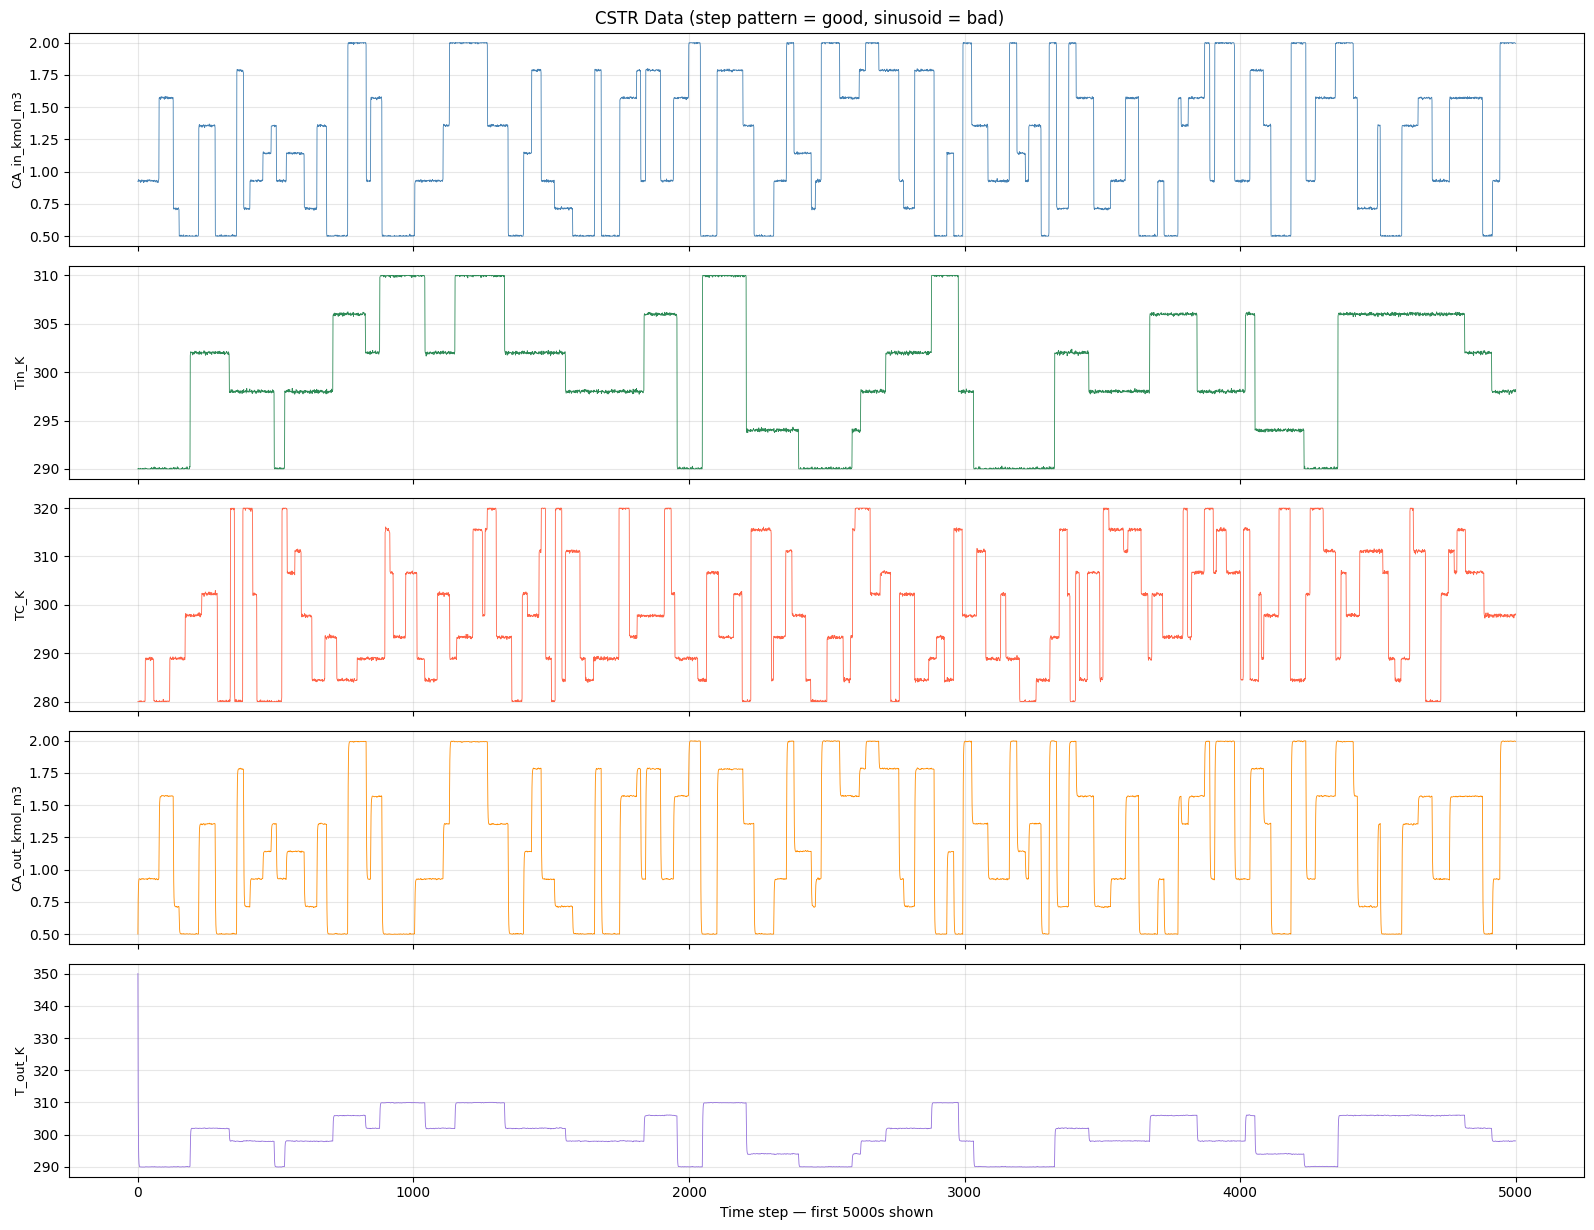

In [60]:
# Plot first 5000 steps — should see step patterns, not sinusoids
n_show = min(5000, len(df))
fig, axes = plt.subplots(len(df.columns), 1,
                         figsize=(16, 2.5*len(df.columns)), sharex=True)
colors = ["steelblue", "seagreen", "tomato", "darkorange", "mediumpurple"]
for i, (col, ax) in enumerate(zip(df.columns, axes)):
    ax.plot(df[col].values[:n_show], lw=0.6, color=colors[i % len(colors)])
    ax.set_ylabel(col, fontsize=9)
    ax.grid(alpha=0.3)
axes[-1].set_xlabel(f"Time step — first {n_show}s shown")
plt.suptitle("CSTR Data (step pattern = good, sinusoid = bad)", fontsize=12)
plt.tight_layout()
plt.show()

In [5]:
# Chronological split — never shuffle time-series data
n         = len(df)
train_end = int(0.70 * n)
val_end   = int(0.85 * n)

train_df = df.iloc[:train_end].copy().reset_index(drop=True)
val_df   = df.iloc[train_end:val_end].copy().reset_index(drop=True)
test_df  = df.iloc[val_end:].copy().reset_index(drop=True)

print(f"Train: {len(train_df):,}   Val: {len(val_df):,}   Test: {len(test_df):,}")

Train: 120,960   Val: 25,920   Test: 25,921


In [6]:
# Fit scalers on training data only — val/test only transformed, never fitted
scaler_X = StandardScaler()
scaler_S = StandardScaler()

X_train = scaler_X.fit_transform(train_df[INPUT_COLS].values)
S_train = scaler_S.fit_transform(train_df[STATE_COLS].values)
X_val   = scaler_X.transform(val_df[INPUT_COLS].values)
S_val   = scaler_S.transform(val_df[STATE_COLS].values)
X_test  = scaler_X.transform(test_df[INPUT_COLS].values)
S_test  = scaler_S.transform(test_df[STATE_COLS].values)

for name, obj in [("scaler_X", scaler_X), ("scaler_S", scaler_S)]:
    with open(os.path.join(SAVE_DIR, f"{name}.pkl"), "wb") as f:
        pickle.dump(obj, f)
print("Scalers fitted and saved")
print(f"Input means: {scaler_X.mean_.round(4)}   stds: {scaler_X.scale_.round(4)}")
print(f"State means: {scaler_S.mean_.round(4)}   stds: {scaler_S.scale_.round(4)}")

# W_STATE: tracking weights normalised by actual output standard deviation
# This ensures a 1-sigma CA error costs the same as a 1-sigma T error
# Using std from the real data distribution (scaler_S.scale_)
CA_std  = float(scaler_S.scale_[0])   # std of CA_out in training data
T_std   = float(scaler_S.scale_[1])   # std of T_out in training data
W_STATE = np.array([1.0 / CA_std**2,  1.0 / T_std**2])

print(f"\nW_STATE = {W_STATE.round(4)}  (scale-normalised by real data std)")
print(f"  CA_out std={CA_std:.4f}  T_out std={T_std:.4f}")
print(f"  CA weight / T weight ratio = {W_STATE[0]/W_STATE[1]:.1f}")

Scalers fitted and saved
Input means: [  1.2403 300.2548 299.9866]   stds: [ 0.4917  6.8964 12.6161]
State means: [  1.2376 300.2547]   stds: [0.4853 6.8434]

W_STATE = [4.2452 0.0214]  (scale-normalised by real data std)
  CA_out std=0.4853  T_out std=6.8434
  CA weight / T weight ratio = 198.8


In [7]:
class CSTRDataset(Dataset):
    """
    Each sample returns 4 items:
      x        : (T, 3)  scaled past inputs [CA_in, Tin, TC]
      s0       : (2,)    scaled state at the start of the prediction window
      future_u : (H, 3)  scaled REAL future inputs — model learns to use this
      y        : (H, 2)  scaled absolute future states [CA_out, T_out] — target

    During NMPC, future_u is replaced with the candidate MV plan.
    Since the model was trained to use future_u, changing it changes predictions.
    This is what makes optimisation work.
    """
    def __init__(self, X_scaled, S_scaled, T=80, H=20):
        self.X = torch.tensor(X_scaled, dtype=torch.float32)
        self.S = torch.tensor(S_scaled, dtype=torch.float32)
        self.T, self.H = T, H
        self.length = len(X_scaled) - T - H + 1

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        x        = self.X[idx : idx + self.T]
        s0       = self.S[idx + self.T - 1]
        future_u = self.X[idx + self.T : idx + self.T + self.H]
        y        = self.S[idx + self.T : idx + self.T + self.H]
        return x, s0, future_u, y


train_ds = CSTRDataset(X_train, S_train, T, H)
val_ds   = CSTRDataset(X_val,   S_val,   T, H)
test_ds  = CSTRDataset(X_test,  S_test,  T, H)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          pin_memory=True, num_workers=2, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          pin_memory=True, num_workers=2, drop_last=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          pin_memory=True, num_workers=2, drop_last=True)

xb, s0b, fub, yb = next(iter(train_loader))
print(f"x        : {xb.shape}   -> [B, T=80, 3]")
print(f"s0       : {s0b.shape}  -> [B, 2]")
print(f"future_u : {fub.shape}  -> [B, H=20, 3]")
print(f"y        : {yb.shape}   -> [B, H=20, 2]")
print(f"Dataset sizes — Train:{len(train_ds):,}  Val:{len(val_ds):,}  Test:{len(test_ds):,}")

x        : torch.Size([128, 80, 3])   -> [B, T=80, 3]
s0       : torch.Size([128, 2])  -> [B, 2]
future_u : torch.Size([128, 20, 3])  -> [B, H=20, 3]
y        : torch.Size([128, 20, 2])   -> [B, H=20, 2]
Dataset sizes — Train:120,861  Val:25,821  Test:25,822


In [61]:
class LSTMPredictor(nn.Module):
    """
    LSTM encodes 80 steps of past input history.
    Current state s0 is projected and added to the encoder output.
    LayerNorm before fusion prevents s0 from dominating the encoder gradient.
    future_u is projected per-step and added to give the model knowledge
    of the proposed future control plan.
    Output: (B, H, 2) — absolute predicted [CA_out, T_out] over the horizon.
    """
    def __init__(self, input_dim=3, state_dim=2, hidden_dim=256,
                 num_layers=2, output_dim=2, horizon=H, dropout=0.2):
        super().__init__()
        self.H = horizon
        self.lstm        = nn.LSTM(input_dim, hidden_dim, num_layers=num_layers,
                                   batch_first=True,
                                   dropout=dropout if num_layers > 1 else 0.0)
        self.state_proj  = nn.Linear(state_dim, hidden_dim)
        self.future_proj = nn.Linear(input_dim, hidden_dim)
        self.norm_ctx    = nn.LayerNorm(hidden_dim)
        self.norm_out    = nn.LayerNorm(hidden_dim)
        self.drop        = nn.Dropout(dropout)
        self.out_fc      = nn.Linear(hidden_dim, output_dim)

    def forward(self, x, s0, future_u):
        out, _  = self.lstm(x)
        ctx     = self.norm_ctx(out[:, -1, :] + self.state_proj(s0))   # (B, hidden)
        ctx     = ctx.unsqueeze(1).expand(-1, self.H, -1)               # (B, H, hidden)
        fut     = self.future_proj(future_u)                            # (B, H, hidden)
        h       = self.drop(self.norm_out(ctx + fut))
        return self.out_fc(h)                                           # (B, H, 2)


_m = LSTMPredictor().to(device)
_x, _s0, _fu = (torch.randn(4, T, 3).to(device),
                 torch.randn(4, 2).to(device),
                 torch.randn(4, H, 3).to(device))
print(f"LSTM output: {_m(_x, _s0, _fu).shape}  -> expect [4, {H}, 2]")
print(f"LSTM params: {sum(p.numel() for p in _m.parameters()):,}")
del _m, _x, _s0, _fu

LSTM output: torch.Size([4, 20, 2])  -> expect [4, 20, 2]
LSTM params: 796,930


In [62]:
class GRUPredictor(nn.Module):
    """Same architecture as LSTMPredictor but with GRU cells — fewer parameters."""
    def __init__(self, input_dim=3, state_dim=2, hidden_dim=256,
                 num_layers=2, output_dim=2, horizon=H, dropout=0.2):
        super().__init__()
        self.H = horizon
        self.gru         = nn.GRU(input_dim, hidden_dim, num_layers=num_layers,
                                  batch_first=True,
                                  dropout=dropout if num_layers > 1 else 0.0)
        self.state_proj  = nn.Linear(state_dim, hidden_dim)
        self.future_proj = nn.Linear(input_dim, hidden_dim)
        self.norm_ctx    = nn.LayerNorm(hidden_dim)
        self.norm_out    = nn.LayerNorm(hidden_dim)
        self.drop        = nn.Dropout(dropout)
        self.out_fc      = nn.Linear(hidden_dim, output_dim)

    def forward(self, x, s0, future_u):
        out, _  = self.gru(x)
        ctx     = self.norm_ctx(out[:, -1, :] + self.state_proj(s0))
        ctx     = ctx.unsqueeze(1).expand(-1, self.H, -1)
        fut     = self.future_proj(future_u)
        h       = self.drop(self.norm_out(ctx + fut))
        return self.out_fc(h)


_m = GRUPredictor().to(device)
_x, _s0, _fu = (torch.randn(4, T, 3).to(device),
                 torch.randn(4, 2).to(device),
                 torch.randn(4, H, 3).to(device))
print(f"GRU output: {_m(_x, _s0, _fu).shape}  -> expect [4, {H}, 2]")
print(f"GRU params: {sum(p.numel() for p in _m.parameters()):,}")
del _m, _x, _s0, _fu

GRU output: torch.Size([4, 20, 2])  -> expect [4, 20, 2]
GRU params: 598,530


In [63]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float()
                        * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])


class TransformerPredictor(nn.Module):
    """
    Causal Transformer encoder over T-step input history.
    Causal mask: each token only attends to itself and earlier tokens.
    Same state + future_u conditioning as LSTM/GRU.
    """
    def __init__(self, input_dim=3, state_dim=2, d_model=128, nhead=8,
                 num_layers=3, dim_ff=512, dropout=0.1, output_dim=2,
                 horizon=H, lookback=T):
        super().__init__()
        assert d_model % nhead == 0
        self.H           = horizon
        self.input_proj  = nn.Linear(input_dim, d_model)
        self.state_proj  = nn.Linear(state_dim, d_model)
        self.future_proj = nn.Linear(input_dim, d_model)
        self.pos_enc     = PositionalEncoding(d_model, dropout=dropout)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.register_buffer("causal_mask",
            torch.triu(torch.full((lookback, lookback), float("-inf")), diagonal=1))
        self.norm_ctx = nn.LayerNorm(d_model)
        self.norm_out = nn.LayerNorm(d_model)
        self.drop     = nn.Dropout(dropout)
        self.out_fc   = nn.Sequential(
            nn.Linear(d_model, d_model), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(d_model, output_dim))

    def forward(self, x, s0, future_u):
        x   = self.pos_enc(self.input_proj(x))
        x   = self.encoder(x, mask=self.causal_mask)
        ctx = self.norm_ctx(x[:, -1, :] + self.state_proj(s0))
        ctx = ctx.unsqueeze(1).expand(-1, self.H, -1)
        fut = self.future_proj(future_u)
        h   = self.drop(self.norm_out(ctx + fut))
        return self.out_fc(h)


_m = TransformerPredictor().to(device)
_x, _s0, _fu = (torch.randn(4, T, 3).to(device),
                 torch.randn(4, 2).to(device),
                 torch.randn(4, H, 3).to(device))
print(f"Transformer output: {_m(_x, _s0, _fu).shape}  -> expect [4, {H}, 2]")
print(f"Transformer params: {sum(p.numel() for p in _m.parameters()):,}")
del _m, _x, _s0, _fu

Transformer output: torch.Size([4, 20, 2])  -> expect [4, 20, 2]
Transformer params: 613,506


In [11]:
# Near-term horizon steps weighted more — NMPC applies only the first move
step_weights = torch.linspace(1.5, 0.7, H).to(device)

def weighted_mse(pred, target):
    err = (pred - target) ** 2
    return (err * step_weights.unsqueeze(0).unsqueeze(-1)).mean()

def train_epoch(loader, model, optimizer):
    model.train()
    total = 0.0
    for x, s0, fu, y in loader:
        x, s0, fu, y = x.to(device), s0.to(device), fu.to(device), y.to(device)
        loss = weighted_mse(model(x, s0, fu), y)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total += loss.item()
    return total / len(loader)

def val_epoch(loader, model):
    model.eval()
    total = 0.0
    with torch.no_grad():
        for x, s0, fu, y in loader:
            x, s0, fu, y = x.to(device), s0.to(device), fu.to(device), y.to(device)
            total += weighted_mse(model(x, s0, fu), y).item()
    return total / len(loader)

def train_model(model, optimizer, name, epochs=EPOCHS):
    scheduler = lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=8, min_lr=1e-6)
    best_val = float("inf")
    tr_hist, vl_hist = [], []
    ckpt = os.path.join(SAVE_DIR, f"{name.lower()}_best.pt")

    for ep in range(epochs):
        tr = train_epoch(train_loader, model, optimizer)
        vl = val_epoch(val_loader, model)
        scheduler.step(vl)
        tr_hist.append(tr)
        vl_hist.append(vl)
        tag = ""
        if vl < best_val:
            best_val = vl
            torch.save({"state": model.state_dict(),
                        "tr": tr_hist, "vl": vl_hist}, ckpt)
            tag = "  <- best"
        lr_now = optimizer.param_groups[0]["lr"]
        print(f"[{name}] {ep+1:03d}/{epochs} | "
              f"Train {tr:.5f} | Val {vl:.5f} | LR {lr_now:.1e}{tag}")

    print(f"\n{name} done — Best Val = {best_val:.6f}\n")
    return tr_hist, vl_hist

In [12]:
lstm_model = LSTMPredictor(num_layers=2).to(device)
lstm_opt   = optim.Adam(lstm_model.parameters(), lr=LR_LSTM, weight_decay=1e-4)
lstm_tr, lstm_vl = train_model(lstm_model, lstm_opt, "LSTM")

[LSTM] 001/30 | Train 0.04472 | Val 0.01285 | LR 3.0e-04  <- best
[LSTM] 002/30 | Train 0.01665 | Val 0.01252 | LR 3.0e-04  <- best
[LSTM] 003/30 | Train 0.01574 | Val 0.01238 | LR 3.0e-04  <- best
[LSTM] 004/30 | Train 0.01525 | Val 0.01225 | LR 3.0e-04  <- best
[LSTM] 005/30 | Train 0.01496 | Val 0.01227 | LR 3.0e-04
[LSTM] 006/30 | Train 0.01479 | Val 0.01220 | LR 3.0e-04  <- best
[LSTM] 007/30 | Train 0.01468 | Val 0.01216 | LR 3.0e-04  <- best
[LSTM] 008/30 | Train 0.01460 | Val 0.01218 | LR 3.0e-04
[LSTM] 009/30 | Train 0.01452 | Val 0.01214 | LR 3.0e-04  <- best
[LSTM] 010/30 | Train 0.01449 | Val 0.01215 | LR 3.0e-04
[LSTM] 011/30 | Train 0.01444 | Val 0.01212 | LR 3.0e-04  <- best
[LSTM] 012/30 | Train 0.01439 | Val 0.01208 | LR 3.0e-04  <- best
[LSTM] 013/30 | Train 0.01435 | Val 0.01208 | LR 3.0e-04
[LSTM] 014/30 | Train 0.01430 | Val 0.01207 | LR 3.0e-04  <- best
[LSTM] 015/30 | Train 0.01428 | Val 0.01207 | LR 3.0e-04  <- best
[LSTM] 016/30 | Train 0.01427 | Val 0.01206 | 

In [13]:
gru_model = GRUPredictor(num_layers=2).to(device)
gru_opt   = optim.Adam(gru_model.parameters(), lr=LR_GRU, weight_decay=1e-4)
gru_tr, gru_vl = train_model(gru_model, gru_opt, "GRU")

[GRU] 001/30 | Train 0.04578 | Val 0.01305 | LR 3.0e-04  <- best
[GRU] 002/30 | Train 0.01657 | Val 0.01253 | LR 3.0e-04  <- best
[GRU] 003/30 | Train 0.01556 | Val 0.01233 | LR 3.0e-04  <- best
[GRU] 004/30 | Train 0.01505 | Val 0.01221 | LR 3.0e-04  <- best
[GRU] 005/30 | Train 0.01479 | Val 0.01221 | LR 3.0e-04  <- best
[GRU] 006/30 | Train 0.01463 | Val 0.01216 | LR 3.0e-04  <- best
[GRU] 007/30 | Train 0.01454 | Val 0.01213 | LR 3.0e-04  <- best
[GRU] 008/30 | Train 0.01447 | Val 0.01214 | LR 3.0e-04
[GRU] 009/30 | Train 0.01443 | Val 0.01212 | LR 3.0e-04  <- best
[GRU] 010/30 | Train 0.01439 | Val 0.01209 | LR 3.0e-04  <- best
[GRU] 011/30 | Train 0.01435 | Val 0.01209 | LR 3.0e-04
[GRU] 012/30 | Train 0.01431 | Val 0.01208 | LR 3.0e-04  <- best
[GRU] 013/30 | Train 0.01429 | Val 0.01208 | LR 3.0e-04  <- best
[GRU] 014/30 | Train 0.01427 | Val 0.01208 | LR 3.0e-04
[GRU] 015/30 | Train 0.01424 | Val 0.01207 | LR 3.0e-04  <- best
[GRU] 016/30 | Train 0.01422 | Val 0.01205 | LR 3.0e

In [14]:
trans_model = TransformerPredictor().to(device)
trans_opt   = optim.Adam(trans_model.parameters(), lr=LR_TRANS, weight_decay=1e-4)
trans_tr, trans_vl = train_model(trans_model, trans_opt, "Transformer")

[Transformer] 001/30 | Train 0.05103 | Val 0.01323 | LR 1.0e-04  <- best
[Transformer] 002/30 | Train 0.01995 | Val 0.01276 | LR 1.0e-04  <- best
[Transformer] 003/30 | Train 0.01845 | Val 0.01232 | LR 1.0e-04  <- best
[Transformer] 004/30 | Train 0.01770 | Val 0.01246 | LR 1.0e-04
[Transformer] 005/30 | Train 0.01721 | Val 0.01212 | LR 1.0e-04  <- best
[Transformer] 006/30 | Train 0.01685 | Val 0.01218 | LR 1.0e-04
[Transformer] 007/30 | Train 0.01661 | Val 0.01220 | LR 1.0e-04
[Transformer] 008/30 | Train 0.01642 | Val 0.01206 | LR 1.0e-04  <- best
[Transformer] 009/30 | Train 0.01627 | Val 0.01213 | LR 1.0e-04
[Transformer] 010/30 | Train 0.01616 | Val 0.01221 | LR 1.0e-04
[Transformer] 011/30 | Train 0.01609 | Val 0.01217 | LR 1.0e-04
[Transformer] 012/30 | Train 0.01604 | Val 0.01222 | LR 1.0e-04
[Transformer] 013/30 | Train 0.01600 | Val 0.01232 | LR 1.0e-04
[Transformer] 014/30 | Train 0.01596 | Val 0.01232 | LR 1.0e-04
[Transformer] 015/30 | Train 0.01594 | Val 0.01241 | LR 1.0

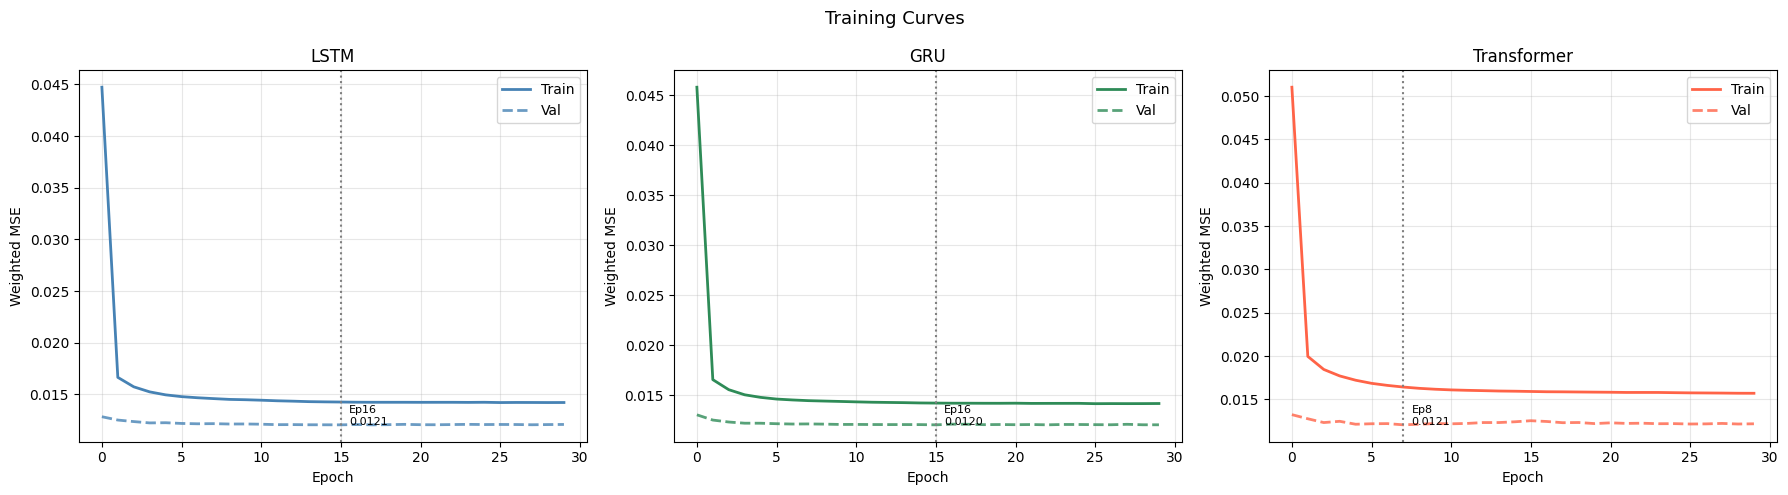

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
runs = [("LSTM", lstm_tr, lstm_vl, "steelblue"),
        ("GRU",  gru_tr,  gru_vl,  "seagreen"),
        ("Transformer", trans_tr, trans_vl, "tomato")]

for ax, (name, tr, vl, color) in zip(axes, runs):
    ax.plot(tr, color=color, lw=2, label="Train")
    ax.plot(vl, color=color, lw=2, ls="--", alpha=0.8, label="Val")
    best = int(np.argmin(vl))
    ax.axvline(best, ls=":", color="gray")
    ax.text(best + 0.5, vl[best], f"Ep{best+1}\n{vl[best]:.4f}", fontsize=8)
    ax.set_title(name)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Weighted MSE")
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle("Training Curves", fontsize=13)
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
def evaluate(loader, model, name):
    model.eval()
    P_list, T_list = [], []
    with torch.inference_mode():
        for x, s0, fu, y in loader:
            P_list.append(
                model(x.to(device), s0.to(device), fu.to(device)).cpu().numpy())
            T_list.append(y.numpy())

    P = np.concatenate(P_list)   # (N, H, 2) scaled
    Y = np.concatenate(T_list)
    P_phys = scaler_S.inverse_transform(P.reshape(-1, 2)).reshape(-1, H, 2)
    Y_phys = scaler_S.inverse_transform(Y.reshape(-1, 2)).reshape(-1, H, 2)

    r2_ca     = [r2_score(Y_phys[:,h,0], P_phys[:,h,0]) for h in range(H)]
    r2_t      = [r2_score(Y_phys[:,h,1], P_phys[:,h,1]) for h in range(H)]
    r2_ca_all = r2_score(Y_phys[:,:,0].ravel(), P_phys[:,:,0].ravel())
    r2_t_all  = r2_score(Y_phys[:,:,1].ravel(), P_phys[:,:,1].ravel())
    rmse_ca   = np.sqrt(mean_squared_error(Y_phys[:,:,0].ravel(), P_phys[:,:,0].ravel()))
    rmse_t    = np.sqrt(mean_squared_error(Y_phys[:,:,1].ravel(), P_phys[:,:,1].ravel()))

    print(f"{'='*50}\n{name}")
    print(f"  CA_out — R2={r2_ca_all:.4f}  RMSE={rmse_ca:.5f} kmol/m3")
    print(f"  T_out  — R2={r2_t_all:.4f}  RMSE={rmse_t:.4f} K")
    return {"name": name, "P": P_phys, "Y": Y_phys,
            "r2_ca": r2_ca, "r2_t": r2_t,
            "r2_ca_all": r2_ca_all, "r2_t_all": r2_t_all,
            "rmse_ca": rmse_ca, "rmse_t": rmse_t}

lstm_res  = evaluate(test_loader, lstm_model,  "LSTM")
gru_res   = evaluate(test_loader, gru_model,   "GRU")
trans_res = evaluate(test_loader, trans_model, "Transformer")

LSTM
  CA_out — R2=0.9827  RMSE=0.06261 kmol/m3
  T_out  — R2=0.9942  RMSE=0.5174 K
GRU
  CA_out — R2=0.9827  RMSE=0.06252 kmol/m3
  T_out  — R2=0.9942  RMSE=0.5149 K
Transformer
  CA_out — R2=0.9824  RMSE=0.06308 kmol/m3
  T_out  — R2=0.9941  RMSE=0.5191 K


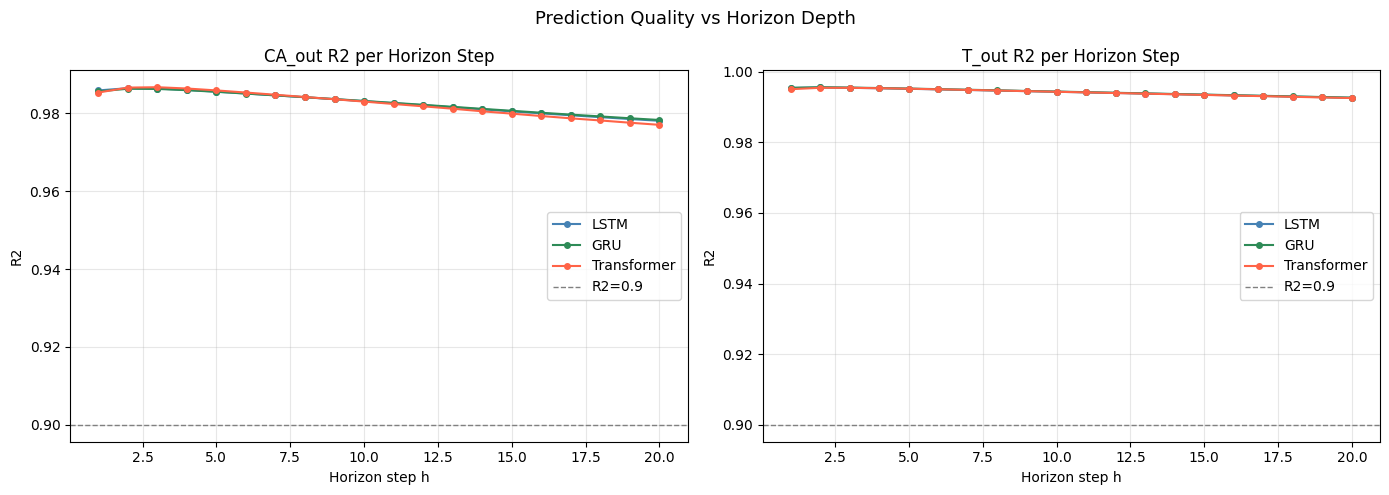

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
steps_h  = np.arange(1, H + 1)
colors3  = ["steelblue", "seagreen", "tomato"]

for res, col in zip([lstm_res, gru_res, trans_res], colors3):
    axes[0].plot(steps_h, res["r2_ca"], marker="o", ms=4, color=col, label=res["name"])
    axes[1].plot(steps_h, res["r2_t"],  marker="o", ms=4, color=col, label=res["name"])

for ax, title in zip(axes, ["CA_out R2 per Horizon Step", "T_out R2 per Horizon Step"]):
    ax.axhline(0.9, ls="--", color="gray", lw=1, label="R2=0.9")
    ax.set_xlabel("Horizon step h")
    ax.set_ylabel("R2")
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle("Prediction Quality vs Horizon Depth", fontsize=13)
plt.tight_layout()
plt.savefig("r2_per_horizon.png", dpi=150, bbox_inches="tight")
plt.show()

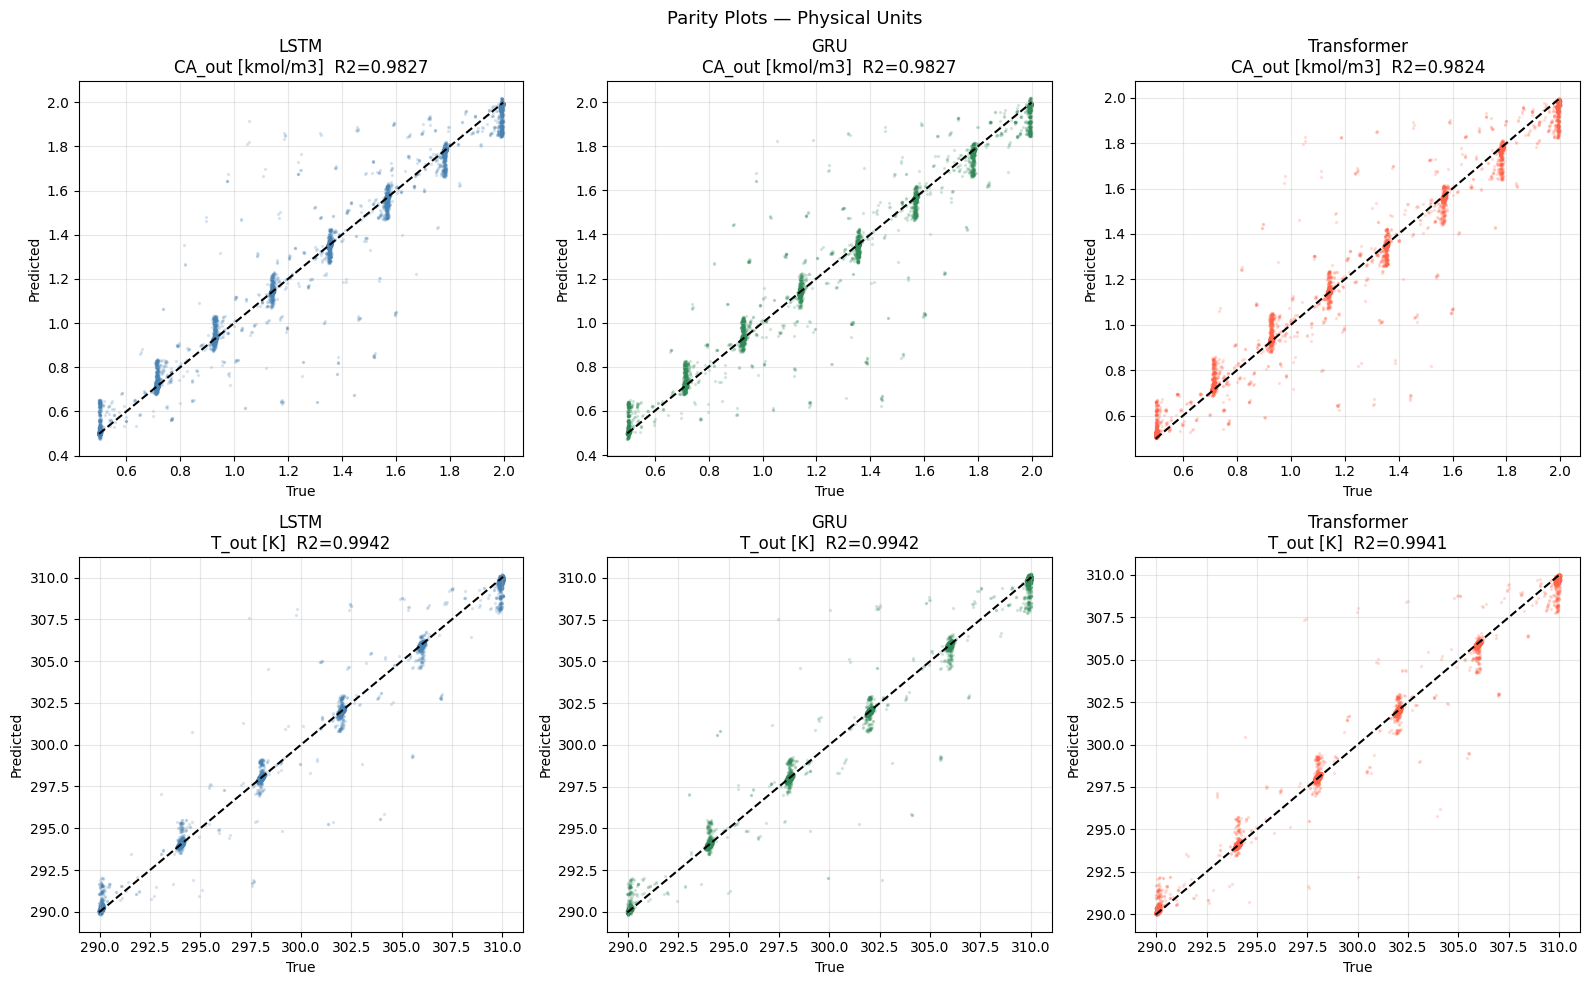

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
labels = ["CA_out [kmol/m3]", "T_out [K]"]

for c, (res, col) in enumerate(zip([lstm_res, gru_res, trans_res], colors3)):
    for r in range(2):
        ax  = axes[r, c]
        yt  = res["Y"][:, :, r].ravel()
        yp  = res["P"][:, :, r].ravel()
        idx = np.random.choice(len(yt), min(10000, len(yt)), replace=False)
        ax.scatter(yt[idx], yp[idx], s=2, alpha=0.15, color=col)
        lo, hi = yt.min(), yt.max()
        ax.plot([lo, hi], [lo, hi], "k--", lw=1.5)
        r2 = res["r2_ca_all"] if r == 0 else res["r2_t_all"]
        ax.set_title(f"{res['name']}\n{labels[r]}  R2={r2:.4f}")
        ax.set_xlabel("True")
        ax.set_ylabel("Predicted")
        ax.grid(alpha=0.3)

plt.suptitle("Parity Plots — Physical Units", fontsize=13)
plt.tight_layout()
plt.savefig("parity_plots.png", dpi=150, bbox_inches="tight")
plt.show()

In [20]:
comparison = pd.DataFrame([{
    "Model":   r["name"],
    "R2_CA":   round(r["r2_ca_all"], 4),
    "R2_T":    round(r["r2_t_all"],  4),
    "RMSE_CA": round(r["rmse_ca"],   5),
    "RMSE_T":  round(r["rmse_t"],    4),
} for r in [lstm_res, gru_res, trans_res]])
print(comparison.to_string(index=False))
comparison

      Model  R2_CA   R2_T  RMSE_CA  RMSE_T
       LSTM 0.9827 0.9942  0.06261  0.5174
        GRU 0.9827 0.9942  0.06252  0.5149
Transformer 0.9824 0.9941  0.06308  0.5191


,Model,R2_CA,R2_T,RMSE_CA,RMSE_T
0,LSTM,0.9827,0.9942,0.06261,0.5174
1,GRU,0.9827,0.9942,0.06252,0.5149
2,Transformer,0.9824,0.9941,0.06308,0.5191


In [64]:
def load_best(ModelClass, filename, **kwargs):
    m    = ModelClass(**kwargs).to(device)
    ckpt = torch.load(os.path.join(SAVE_DIR, filename), map_location=device)
    m.load_state_dict(ckpt["state"])
    m.eval()
    print(f"Loaded {filename}")
    return m

lstm_model  = load_best(LSTMPredictor,        "lstm_best.pt",        num_layers=2)
gru_model   = load_best(GRUPredictor,         "gru_best.pt",         num_layers=2)
trans_model = load_best(TransformerPredictor, "transformer_best.pt")

Loaded lstm_best.pt
Loaded gru_best.pt
Loaded transformer_best.pt


In [65]:
def cstr_deriv(CA, T, CAin, Tin, TC):
    F=1.0; V=1.0; k0=1e6; E=5e4; R=8.314
    dH=-4.5e4; rho=1000.0; Cp=4180.0; UA=1.5e4
    k  = k0 * np.exp(-E / (R * max(T, 250.0)))
    rA = k * max(CA, 0.0)
    dCA = (F/V) * (CAin - CA) - rA
    dT  = (F/V) * (Tin - T) + (-dH / (rho*Cp)) * rA + (UA / (rho*Cp*V)) * (TC - T)
    return np.array([dCA, dT])

def rk4_step(state, u, dt=1.0):
    k1 = cstr_deriv(*state, *u)
    k2 = cstr_deriv(*(state + 0.5*dt*k1), *u)
    k3 = cstr_deriv(*(state + 0.5*dt*k2), *u)
    k4 = cstr_deriv(*(state + dt*k3),     *u)
    ns = state + (dt/6) * (k1 + 2*k2 + 2*k3 + k4)
    ns[0] = max(ns[0], 0.0)   # CA can never be negative
    return ns

# Nominal MV operating point — centre of training data distribution
SS_CA_IN = float(scaler_X.mean_[INPUT_COLS.index("CA_in_kmol_m3")])
SS_TIN   = float(scaler_X.mean_[INPUT_COLS.index("Tin_K")])
SS_TC    = float(scaler_X.mean_[INPUT_COLS.index("TC_K")])

# Run RK4 to TRUE mathematical steady state
# The scaler mean of the output is NOT the same as the ODE fixed point —
# it is the average of a random excitation trajectory.
# Using the wrong value here creates a permanent T_out offset in NMPC.
_s = np.array([float(scaler_S.mean_[0]), float(scaler_S.mean_[1])])
for _ in range(20000):
    _s_new = rk4_step(_s, [SS_CA_IN, SS_TIN, SS_TC])
    if np.max(np.abs(_s_new - _s)) < 1e-10:
        break
    _s = _s_new

SS_CA = float(_s[0])
SS_T  = float(_s[1])

print(f"Nominal inputs : CA_in={SS_CA_IN:.4f}  Tin={SS_TIN:.2f}  TC={SS_TC:.2f}")
print(f"TRUE SS output : CA_out={SS_CA:.6f}  T_out={SS_T:.4f}")
print(f"Scaler mean    : CA_out={scaler_S.mean_[0]:.6f}  T_out={scaler_S.mean_[1]:.4f}")
print(f"Offset         : dCA={SS_CA - scaler_S.mean_[0]:+.6f}  "
      f"dT={SS_T - scaler_S.mean_[1]:+.4f}")

Nominal inputs : CA_in=1.2403  Tin=300.25  TC=299.99
TRUE SS output : CA_out=1.237825  T_out=300.2539
Scaler mean    : CA_out=1.237598  T_out=300.2547
Offset         : dCA=+0.000227  dT=-0.0008


In [66]:
# Precompute scaler parameters as tensors — all on device
X_mean_t  = torch.tensor(scaler_X.mean_,  dtype=torch.float32, device=device)
X_scale_t = torch.tensor(scaler_X.scale_, dtype=torch.float32, device=device)
S_mean_t  = torch.tensor(scaler_S.mean_,  dtype=torch.float32, device=device)
S_scale_t = torch.tensor(scaler_S.scale_, dtype=torch.float32, device=device)
W_STATE_t = torch.tensor(W_STATE, dtype=torch.float32, device=device)
W_DERIV_t = torch.tensor(W_DERIV, dtype=torch.float32, device=device)


def nmpc_cost_and_grad(mv_flat, model, x_buf_phys, s0_phys,
                       setpoint, u_prev, Tin_k, int_err):
    """
    Returns (cost, gradient) using exact PyTorch autograd.
    All tensors on device. Model switches to train() for CuDNN RNN
    backward compatibility, then back to eval() after gradient computed.
    Dropout layers are explicitly kept in eval() so predictions are deterministic.
    """
    # CuDNN RNN backward requires train mode
    model.train()
    # But keep dropout deterministic during NMPC
    for m in model.modules():
        if isinstance(m, nn.Dropout):
            m.eval()

    mv_t = torch.tensor(mv_flat, dtype=torch.float32,
                        requires_grad=True, device=device)

    mv2  = mv_t.view(Nc, 2)
    full = torch.cat([mv2, mv2[-1:].expand(Np - Nc, -1)], dim=0)   # (Np, 2)

    x_sc  = torch.tensor(scaler_X.transform(x_buf_phys),
                         dtype=torch.float32, device=device).unsqueeze(0)  # (1,T,3)

    s0_sc = torch.tensor(scaler_S.transform(s0_phys.reshape(1, -1))[0],
                         dtype=torch.float32, device=device).unsqueeze(0)  # (1,2)

    Tin_col     = torch.full((Np, 1), float(Tin_k), device=device)
    future_phys = torch.cat([full[:, 0:1], Tin_col, full[:, 1:2]], dim=1)  # (Np,3)
    future_sc   = ((future_phys - X_mean_t) / X_scale_t).unsqueeze(0)     # (1,Np,3)

    pred_sc   = model(x_sc, s0_sc, future_sc)           # (1, Np, 2)
    pred_phys = pred_sc[0] * S_scale_t + S_mean_t       # (Np, 2)

    sp_t    = torch.tensor(setpoint + int_err, dtype=torch.float32, device=device)
    e       = sp_t - pred_phys
    J_track = torch.sum(W_STATE_t * torch.sum(e**2, dim=0))

    prev_t = torch.tensor(u_prev, dtype=torch.float32, device=device)
    J_move = torch.zeros(1, device=device)
    for i in range(Nc):
        J_move = J_move + torch.sum(W_DERIV_t * (mv2[i] - prev_t)**2)
        prev_t = mv2[i]

    J = J_track + J_move.squeeze()
    J.backward()

    cost = float(J.item())
    grad = mv_t.grad.detach().cpu().numpy().astype(np.float64)

    model.eval()  # restore eval mode
    return cost, grad


SLSQP_BOUNDS = [(MV_MIN[j % 2], MV_MAX[j % 2]) for j in range(Nc * 2)]
print(f"nmpc_cost_and_grad defined on {device}")
print("Dropout kept deterministic during NMPC gradient computation")

nmpc_cost_and_grad defined on cuda
Dropout kept deterministic during NMPC gradient computation


In [67]:
def run_nmpc(model, model_name, setpoints_arr, disturbances=None):
    """
    Closed-loop NMPC.
    1. Exact autograd gradients (jac=True) — fixes optimizer blindness
    2. Integral anti-windup — fixes steady-state offset
    3. True RK4 SS initialisation — fixes T_out offset at t=0
    """
    state  = np.array([SS_CA, SS_T])
    x_buf  = np.tile([SS_CA_IN, SS_TIN, SS_TC], (T, 1)).astype(float)
    u_prev = np.array([SS_CA_IN, SS_TC])

    Y_log = np.zeros((N_SIM, 2))
    U_log = np.zeros((N_SIM, 2))
    T_log = np.zeros(N_SIM)

    Ki      = np.array([0.015, 0.015])
    int_err = np.zeros(2)
    I_MAX   = np.array([0.1, 1.0])

    print(f"Running {model_name} NMPC ({N_SIM} steps)...")

    for k in range(N_SIM):
        Tin_k = float(disturbances[k]) if disturbances is not None else SS_TIN
        sp_k  = setpoints_arr[k]

        u_plant = np.array([u_prev[0], Tin_k, u_prev[1]])
        state   = rk4_step(state, u_plant)
        y_meas  = state + np.random.randn(2) * np.array([0.001, 0.05])
        Y_log[k] = y_meas
        U_log[k] = u_prev

        if k > 0 and np.any(sp_k != setpoints_arr[k - 1]):
            int_err = np.zeros(2)

        err     = sp_k - y_meas
        int_err = np.clip(int_err + Ki * err, -I_MAX, I_MAX)

        t0 = time.perf_counter()
        res = minimize(
            nmpc_cost_and_grad,
            x0     = np.tile(u_prev, Nc).astype(np.float64),
            args   = (model, x_buf, y_meas, sp_k, u_prev, Tin_k, int_err),
            jac    = True,
            method = "SLSQP",
            bounds = SLSQP_BOUNDS,
            options= {"maxiter": 150, "ftol": 1e-8, "disp": False}
        )
        T_log[k] = time.perf_counter() - t0

        mv2_opt = res.x.reshape(Nc, 2)
        u_new   = np.clip(mv2_opt[0], MV_MIN, MV_MAX)

        x_buf  = np.vstack([x_buf[1:], [u_new[0], Tin_k, u_new[1]]])
        u_prev = u_new

        if (k + 1) % 50 == 0:
            print(f"  step {k+1:3d}/{N_SIM} | "
                  f"CA={y_meas[0]:.4f} sp={sp_k[0]:.4f} | "
                  f"T={y_meas[1]:.2f} sp={sp_k[1]:.2f} | "
                  f"I=[{int_err[0]:+.4f},{int_err[1]:+.3f}] | "
                  f"solve={T_log[k]*1000:.1f}ms")

    IAE_CA = float(np.sum(np.abs(Y_log[:, 0] - setpoints_arr[:, 0])))
    IAE_T  = float(np.sum(np.abs(Y_log[:, 1] - setpoints_arr[:, 1])))
    print(f"  Done — IAE_CA={IAE_CA:.3f}  IAE_T={IAE_T:.3f}  "
          f"avg_solve={T_log.mean()*1000:.1f}ms")
    return {"name": model_name, "Y": Y_log, "U": U_log,
            "SP": setpoints_arr, "times": T_log,
            "IAE_CA": IAE_CA, "IAE_T": IAE_T}

In [68]:
np.random.seed(42)
steps = np.arange(N_SIM)

# Servo: step changes in both setpoints
SP_servo = np.column_stack([
    np.where(steps < 50,  SS_CA,
    np.where(steps < 120, SS_CA + 0.15, SS_CA + 0.25)),
    np.where(steps < 50,  SS_T,
    np.where(steps < 120, SS_T  + 1.0,  SS_T  + 1.5)),
])

# Regulatory: hold SS setpoint, apply Tin disturbance steps
TIN_dist = np.where(steps < 50,  SS_TIN,
           np.where(steps < 120, SS_TIN + 1.0, SS_TIN + 2.0))
SP_reg   = np.tile([SS_CA, SS_T], (N_SIM, 1))

print("Servo setpoints:")
print(f"  CA_sp: {SS_CA:.4f} -> {SS_CA+0.15:.4f} -> {SS_CA+0.25:.4f}")
print(f"  T_sp : {SS_T:.2f}  -> {SS_T+1.0:.2f}  -> {SS_T+1.5:.2f}")
print(f"\nDisturbance: Tin {SS_TIN:.2f} -> {SS_TIN+1:.2f} -> {SS_TIN+2:.2f} K")

Servo setpoints:
  CA_sp: 1.2378 -> 1.3878 -> 1.4878
  T_sp : 300.25  -> 301.25  -> 301.75

Disturbance: Tin 300.25 -> 301.25 -> 302.25 K


In [69]:
controllers = [
    (lstm_model,  "LSTM"),
    (gru_model,   "GRU"),
    (trans_model, "Transformer"),
]
servo_results = [run_nmpc(m, n, SP_servo)          for m, n in controllers]
reg_results   = [run_nmpc(m, n, SP_reg, TIN_dist)  for m, n in controllers]

Running LSTM NMPC (200 steps)...
  step  50/200 | CA=1.2377 sp=1.2378 | T=300.24 sp=300.25 | I=[+0.0003,+0.003] | solve=64.2ms
  step 100/200 | CA=1.3892 sp=1.3878 | T=300.21 sp=301.25 | I=[+0.0024,+0.740] | solve=431.1ms
  step 150/200 | CA=1.4894 sp=1.4878 | T=300.32 sp=301.75 | I=[+0.0019,+0.667] | solve=167.4ms
  step 200/200 | CA=1.4884 sp=1.4878 | T=300.37 sp=301.75 | I=[+0.0013,+1.000] | solve=125.0ms
  Done — IAE_CA=0.600  IAE_T=187.655  avg_solve=327.9ms
Running GRU NMPC (200 steps)...
  step  50/200 | CA=1.2370 sp=1.2378 | T=300.18 sp=300.25 | I=[-0.0000,+0.004] | solve=141.9ms
  step 100/200 | CA=1.3878 sp=1.3878 | T=300.27 sp=301.25 | I=[+0.0023,+0.756] | solve=181.8ms
  step 150/200 | CA=1.4890 sp=1.4878 | T=300.24 sp=301.75 | I=[+0.0021,+0.673] | solve=125.6ms
  step 200/200 | CA=1.4882 sp=1.4878 | T=300.26 sp=301.75 | I=[+0.0014,+1.000] | solve=209.2ms
  Done — IAE_CA=0.620  IAE_T=191.873  avg_solve=205.5ms
Running Transformer NMPC (200 steps)...
  step  50/200 | CA=1.23

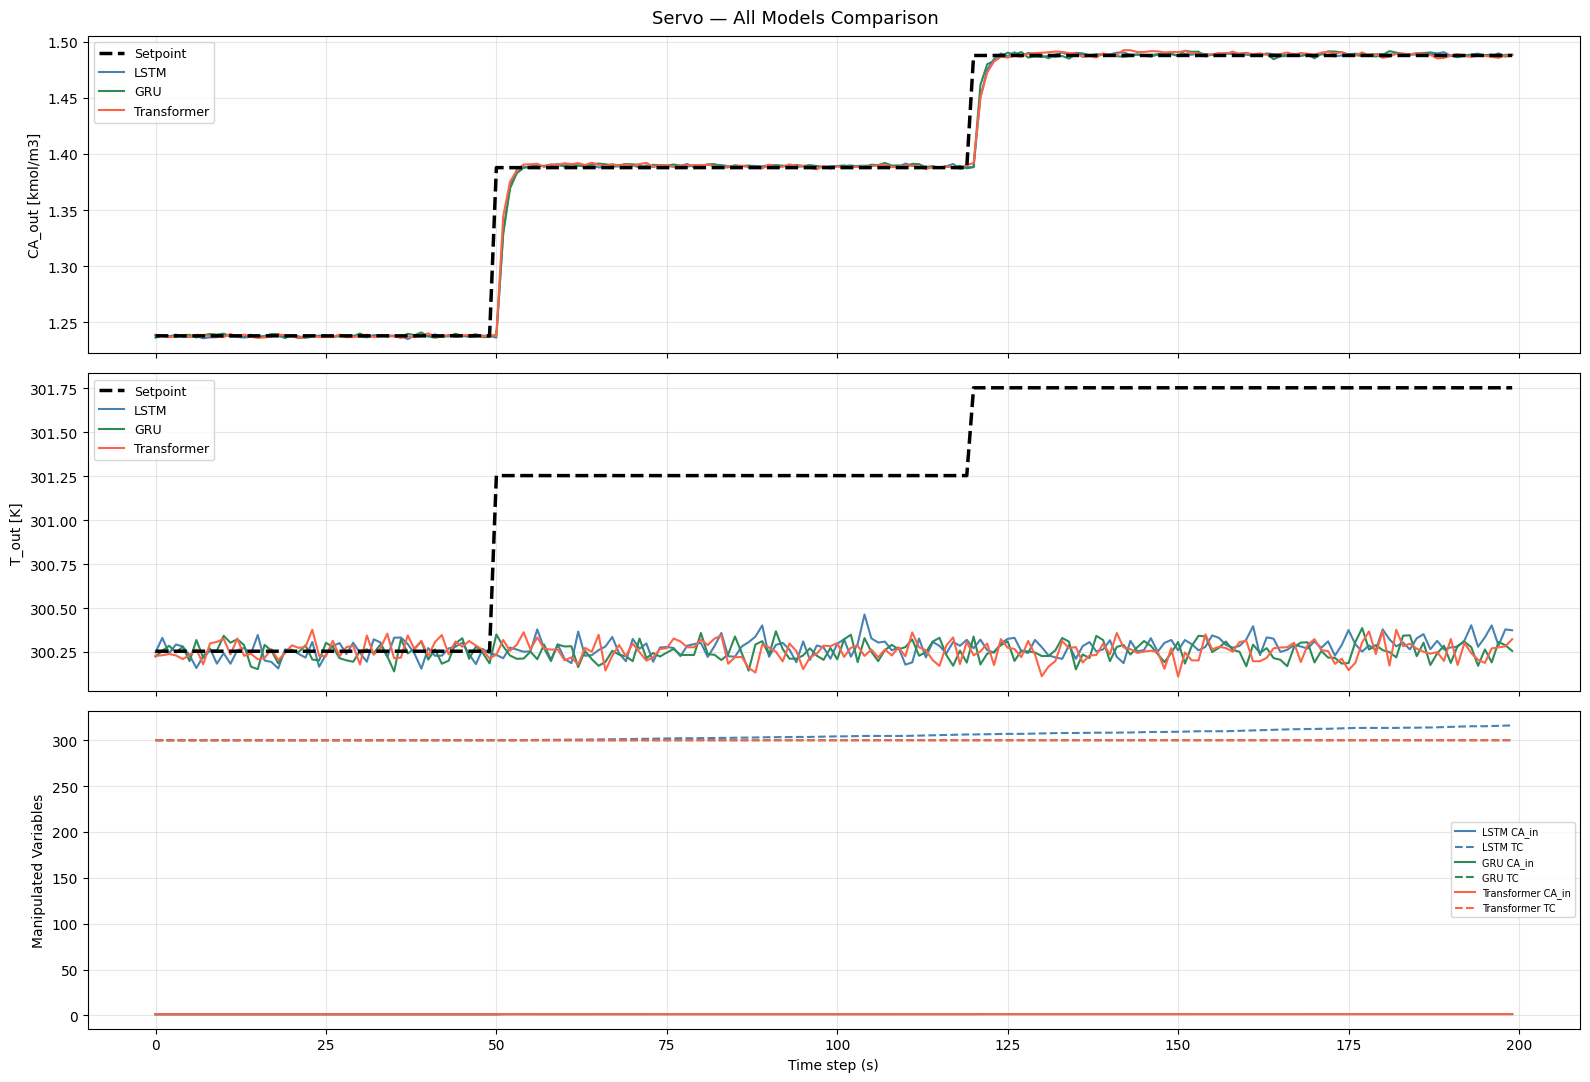

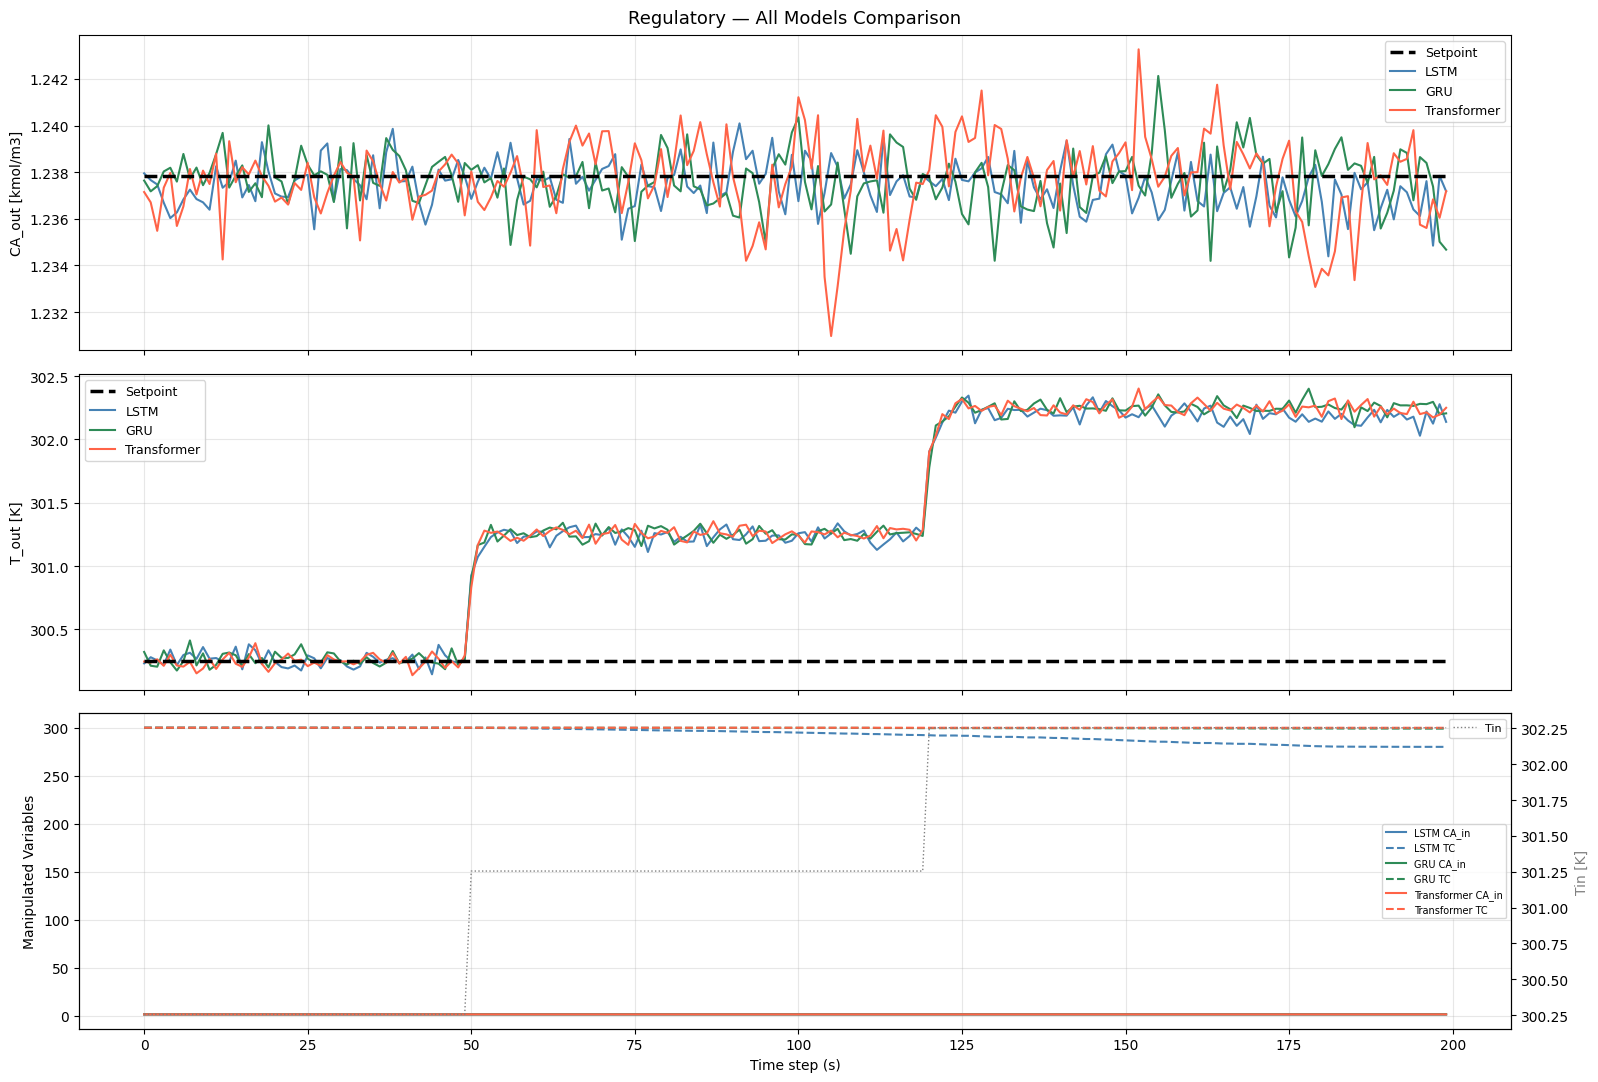

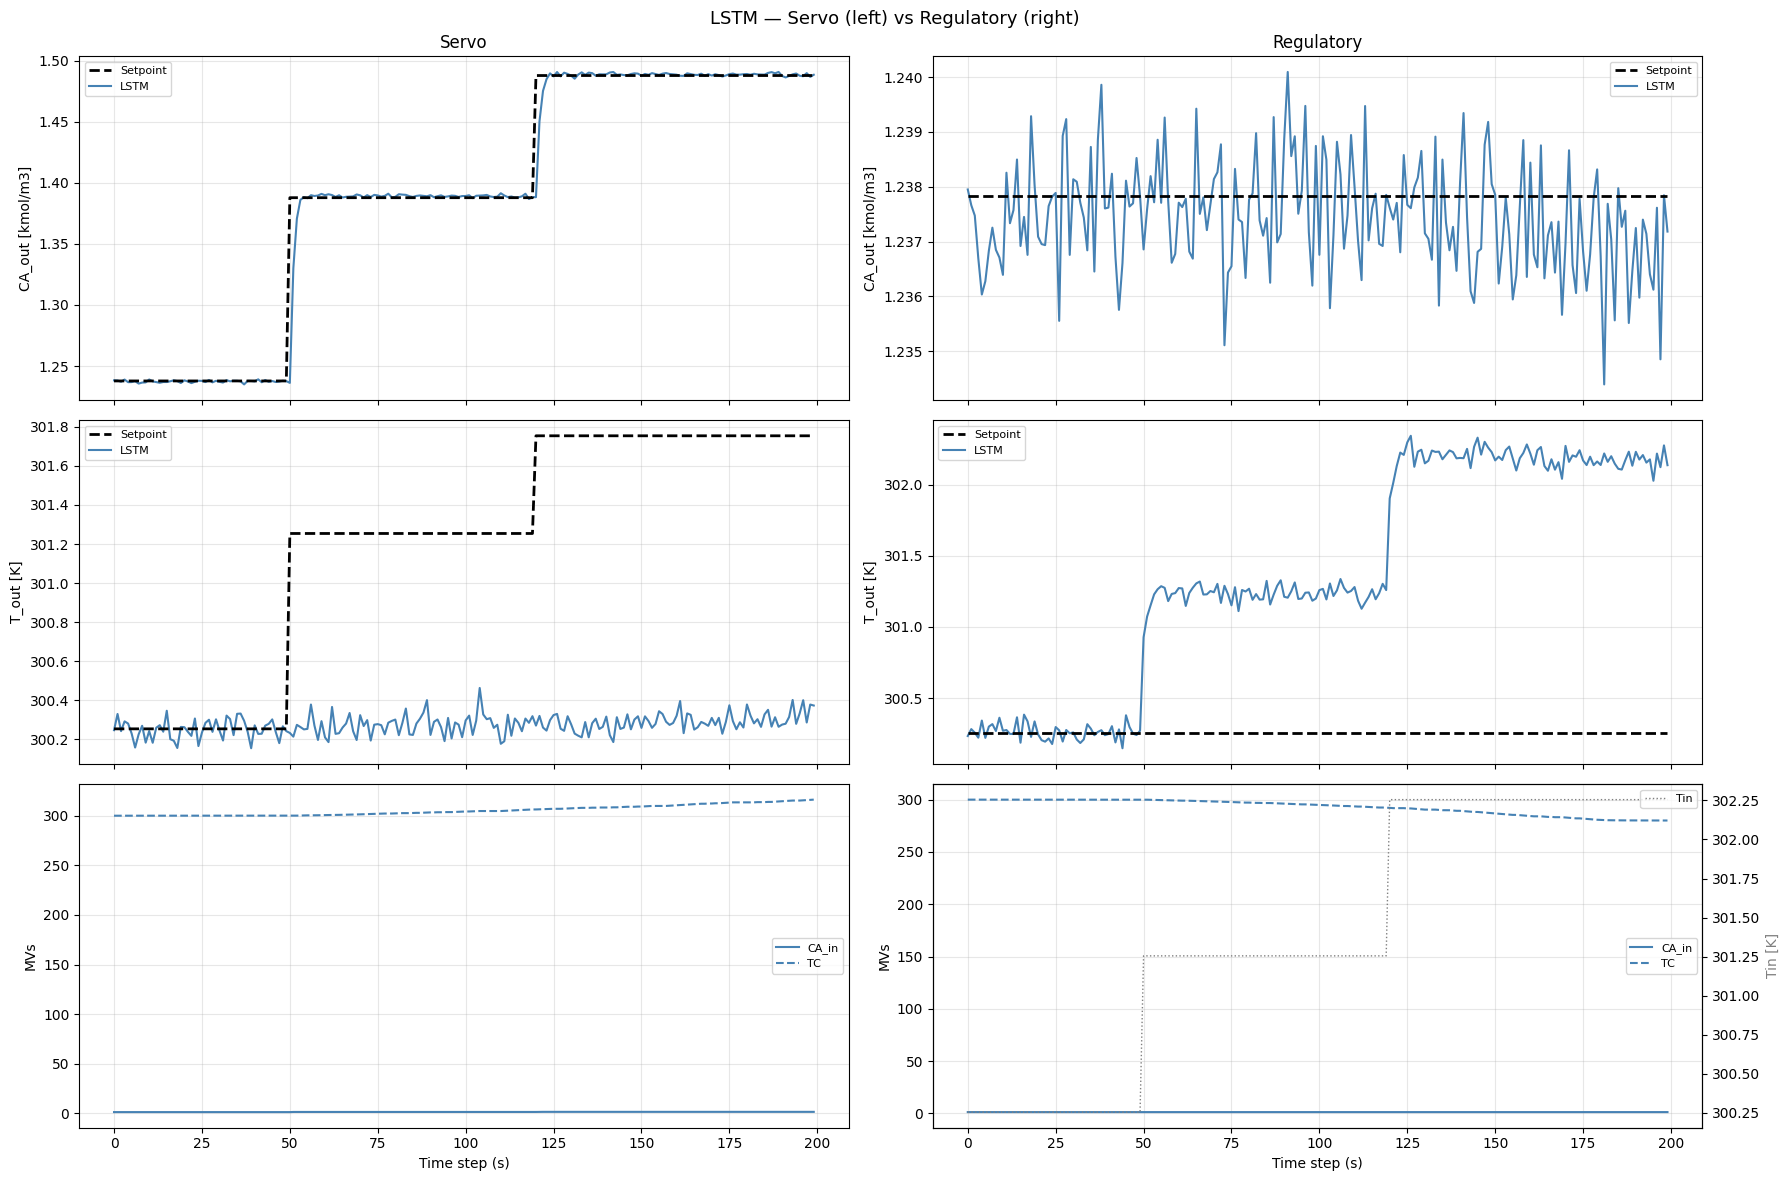

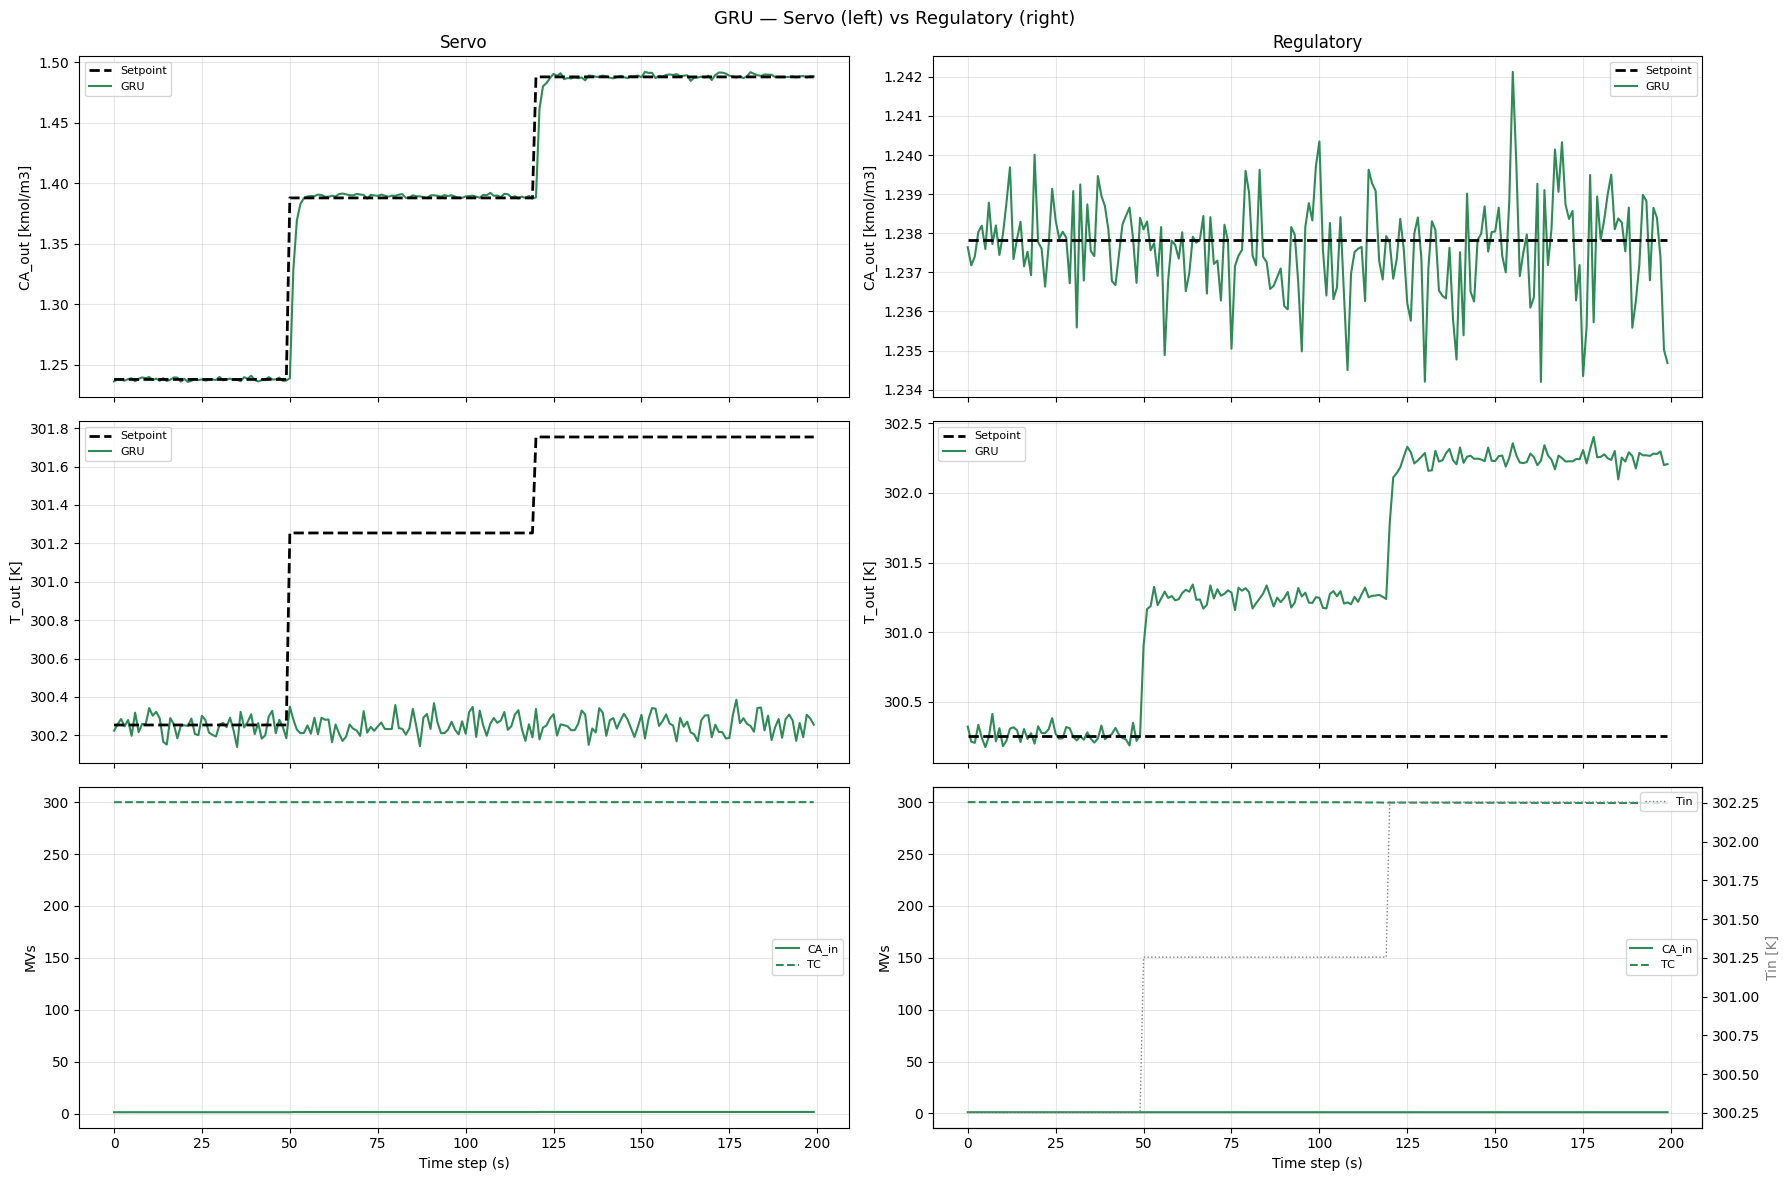

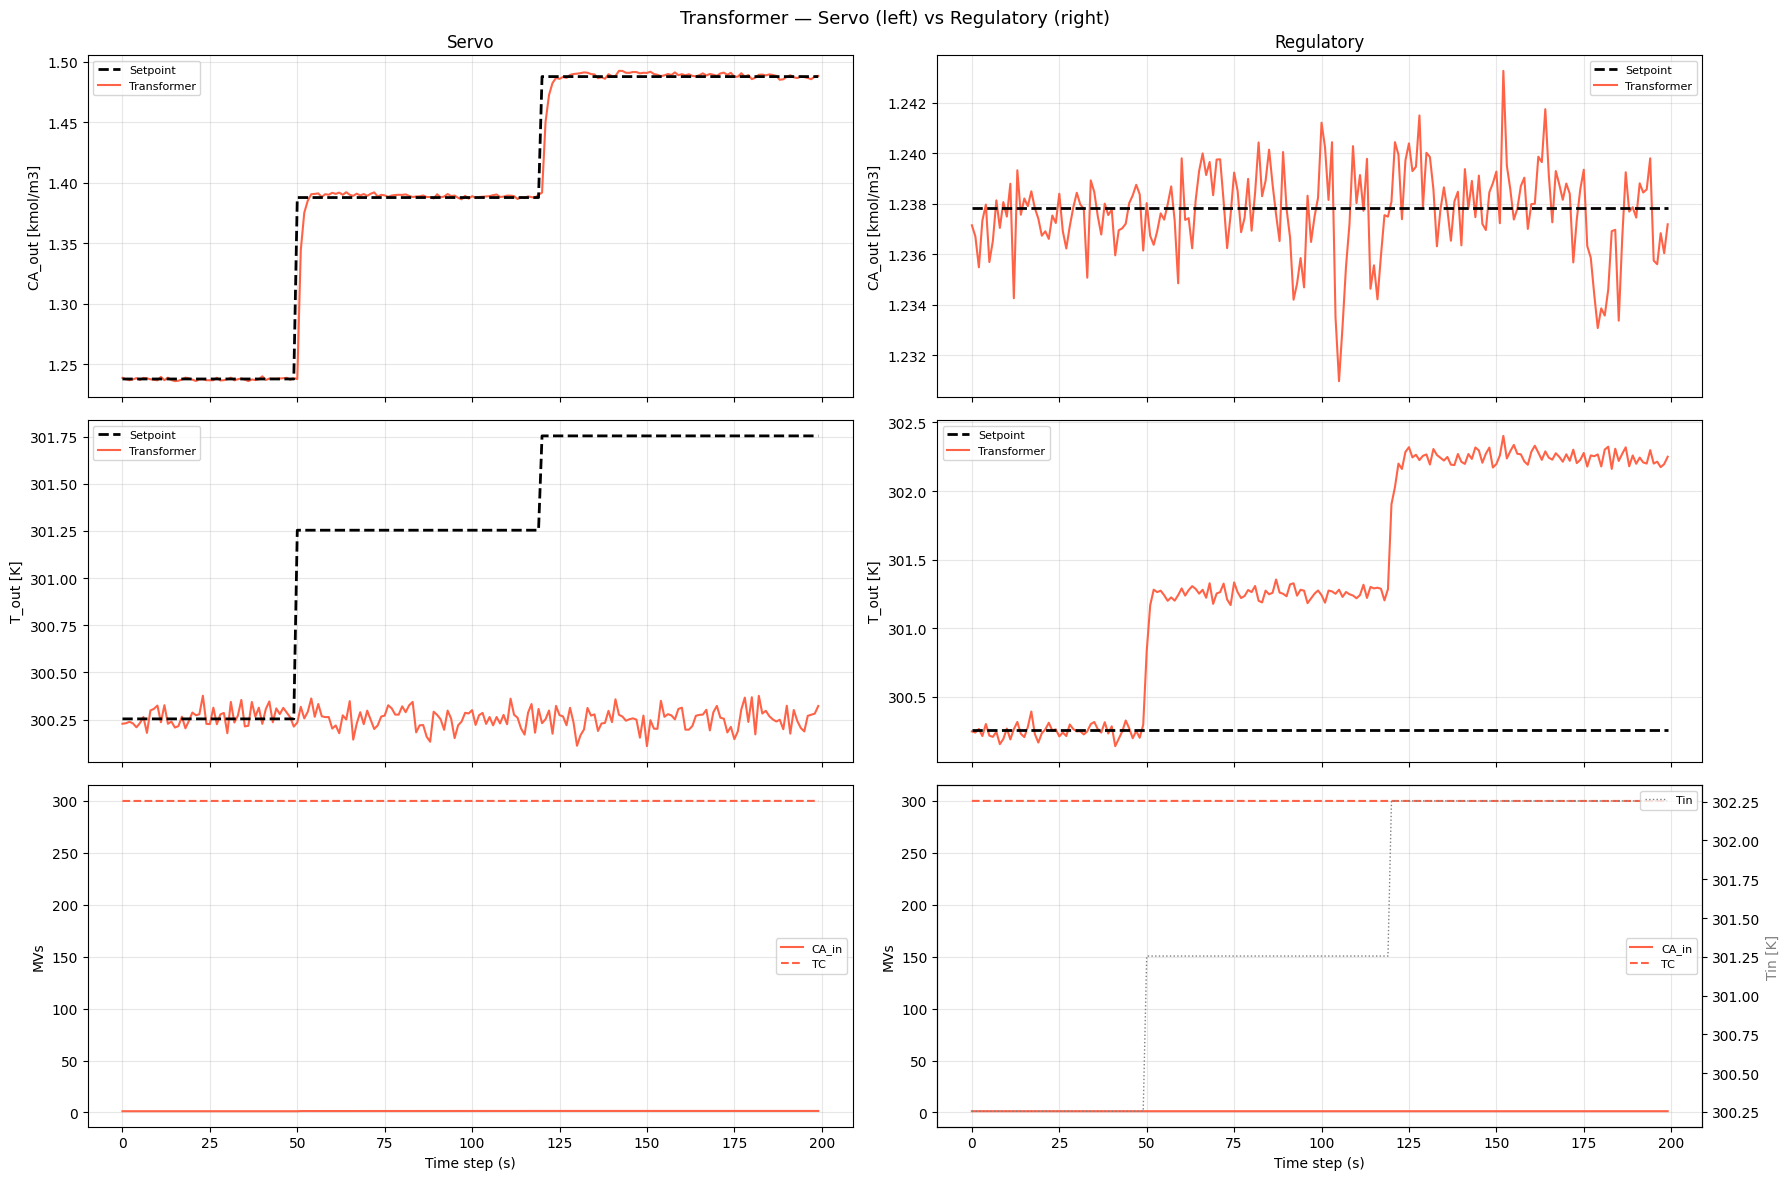

In [70]:
def plot_cl_combined(results, SP, title, disturbance=None):
    """All three models on one figure — for comparison."""
    fig, axes = plt.subplots(3, 1, figsize=(16, 11), sharex=True)
    cols = ["steelblue", "seagreen", "tomato"]

    for i in range(2):
        axes[i].plot(SP[:, i], "k--", lw=2.5, label="Setpoint", zorder=5)
        for res, col in zip(results, cols):
            axes[i].plot(res["Y"][:, i], color=col, lw=1.5, label=res["name"])
        axes[i].set_ylabel(["CA_out [kmol/m3]", "T_out [K]"][i])
        axes[i].legend(fontsize=9); axes[i].grid(alpha=0.3)

    for res, col in zip(results, cols):
        axes[2].plot(res["U"][:, 0], color=col, lw=1.5, label=f"{res['name']} CA_in")
        axes[2].plot(res["U"][:, 1], color=col, lw=1.5, ls="--", label=f"{res['name']} TC")

    if disturbance is not None:
        ax2 = axes[2].twinx()
        ax2.plot(disturbance, "gray", lw=1, ls=":", label="Tin")
        ax2.set_ylabel("Tin [K]", color="gray")
        ax2.legend(loc="upper right", fontsize=8)

    axes[2].set_ylabel("Manipulated Variables")
    axes[2].set_xlabel("Time step (s)")
    axes[2].legend(fontsize=7); axes[2].grid(alpha=0.3)
    plt.suptitle(title, fontsize=13)
    plt.tight_layout(); plt.show()


def plot_cl_per_model(servo_res, reg_res, SP_servo, SP_reg, disturbance=None):
    """
    One figure per model, each with two columns:
    left = servo, right = regulatory.
    Rows: CA_out | T_out | MVs
    """
    cols = ["steelblue", "seagreen", "tomato"]

    for res_s, res_r, col in zip(servo_res, reg_res, cols):
        name = res_s["name"]
        fig, axes = plt.subplots(3, 2, figsize=(18, 12), sharex="col")
        fig.suptitle(f"{name} — Servo (left) vs Regulatory (right)", fontsize=13)

        for col_idx, (res, SP, dist, scenario) in enumerate([
            (res_s, SP_servo, None,        "Servo"),
            (res_r, SP_reg,   disturbance, "Regulatory"),
        ]):
            # CA_out
            axes[0, col_idx].plot(SP[:, 0], "k--", lw=2, label="Setpoint", zorder=5)
            axes[0, col_idx].plot(res["Y"][:, 0], color=col, lw=1.5, label=name)
            axes[0, col_idx].set_ylabel("CA_out [kmol/m3]")
            axes[0, col_idx].set_title(scenario)
            axes[0, col_idx].legend(fontsize=8); axes[0, col_idx].grid(alpha=0.3)

            # T_out
            axes[1, col_idx].plot(SP[:, 1], "k--", lw=2, label="Setpoint", zorder=5)
            axes[1, col_idx].plot(res["Y"][:, 1], color=col, lw=1.5, label=name)
            axes[1, col_idx].set_ylabel("T_out [K]")
            axes[1, col_idx].legend(fontsize=8); axes[1, col_idx].grid(alpha=0.3)

            # MVs
            axes[2, col_idx].plot(res["U"][:, 0], color=col, lw=1.5, label="CA_in")
            axes[2, col_idx].plot(res["U"][:, 1], color=col, lw=1.5, ls="--", label="TC")
            if dist is not None:
                ax2 = axes[2, col_idx].twinx()
                ax2.plot(dist, "gray", lw=1, ls=":", label="Tin")
                ax2.set_ylabel("Tin [K]", color="gray")
                ax2.legend(loc="upper right", fontsize=8)
            axes[2, col_idx].set_ylabel("MVs")
            axes[2, col_idx].set_xlabel("Time step (s)")
            axes[2, col_idx].legend(fontsize=8); axes[2, col_idx].grid(alpha=0.3)

        plt.tight_layout()
        plt.savefig(f"nmpc_{name.lower()}_servo_reg.png", dpi=150, bbox_inches="tight")
        plt.show()


# Combined comparison plots
plot_cl_combined(servo_results, SP_servo, "Servo — All Models Comparison")
plot_cl_combined(reg_results,   SP_reg,   "Regulatory — All Models Comparison",
                 disturbance=TIN_dist)

# Per-model plots (servo left, regulatory right)
plot_cl_per_model(servo_results, reg_results, SP_servo, SP_reg,
                  disturbance=TIN_dist)

In [71]:
def settling_time(y, sp, tol=0.02):
    sp_vals = np.unique(sp)
    sp_vals = sp_vals[sp_vals != sp_vals[0]]
    if len(sp_vals) == 0:
        return np.nan
    band = tol * abs(sp_vals[0])
    for k in range(len(y)):
        if np.all(np.abs(y[k:] - sp[k:]) <= band):
            return k
    return np.nan

def ISE(y, sp):  return float(np.sum((y - sp)**2))
def ITAE(y, sp): return float(np.sum(np.arange(len(y)) * np.abs(y - sp)))
def OS(y, sp):
    sp_final = np.mean(sp[sp != sp[0]])
    if abs(sp_final) < 1e-12:
        return np.nan
    return max(0.0, (np.max(y) - sp_final) / abs(sp_final) * 100)

def build_metrics(results, scenario):
    rows = []
    for r in results:
        yCA, yT   = r["Y"][:, 0], r["Y"][:, 1]
        spCA, spT = r["SP"][:, 0], r["SP"][:, 1]
        row = {
            "Model":   r["name"],
            "IAE_CA":  round(r["IAE_CA"], 3),
            "IAE_T":   round(r["IAE_T"],  3),
            "ISE_CA":  round(ISE(yCA, spCA), 3),
            "ISE_T":   round(ISE(yT,  spT),  3),
            "ITAE_CA": round(ITAE(yCA, spCA), 1),
            "ITAE_T":  round(ITAE(yT,  spT),  1),
            "Solve_ms":round(r["times"].mean() * 1000, 2),
        }
        if scenario == "servo":
            row.update({
                "Ts_CA":    settling_time(yCA, spCA),
                "Ts_T":     settling_time(yT,  spT),
                "OS_CA(%)": round(OS(yCA, spCA), 2),
                "OS_T(%)":  round(OS(yT,  spT),  2),
            })
        else:
            row.update({
                "MaxDev_CA": round(np.max(np.abs(yCA - spCA)), 4),
                "MaxDev_T":  round(np.max(np.abs(yT  - spT)),  4),
            })
        rows.append(row)
    return pd.DataFrame(rows)

servo_df = build_metrics(servo_results, "servo")
reg_df   = build_metrics(reg_results,   "reg")

print("SERVO TRACKING");      print("="*70); display(servo_df)
print("\nREGULATORY REJECTION"); print("="*70); display(reg_df)

SERVO TRACKING


,Model,IAE_CA,IAE_T,ISE_CA,ISE_T,ITAE_CA,ITAE_T,Solve_ms,Ts_CA,Ts_T,OS_CA(%),OS_T(%)
0,LSTM,0.600,187.655,0.038,238.932,52.7,24467.4,327.93,122,0,3.44,0.0
1,GRU,0.620,191.873,0.037,249.966,53.6,25065.4,205.48,121,0,3.53,0.0
2,Transformer,0.645,191.901,0.036,250.379,59.4,25099.2,296.33,122,0,3.57,0.0



REGULATORY REJECTION


,Model,IAE_CA,IAE_T,ISE_CA,ISE_T,ITAE_CA,ITAE_T,Solve_ms,MaxDev_CA,MaxDev_T
0,LSTM,0.171,225.403,0.000,367.379,18.2,30525.1,323.99,0.0034,2.0920
1,GRU,0.191,230.632,0.000,386.017,21.7,31325.7,231.91,0.0043,2.1468
2,Transformer,0.258,230.437,0.001,385.797,28.5,31315.1,308.11,0.0069,2.1482


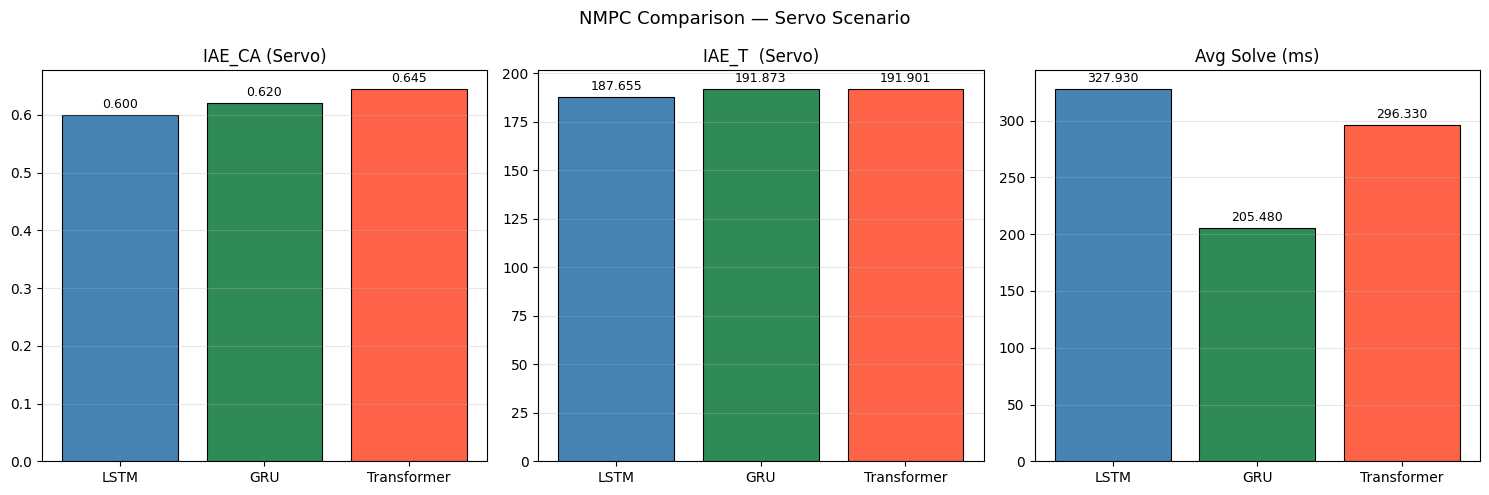

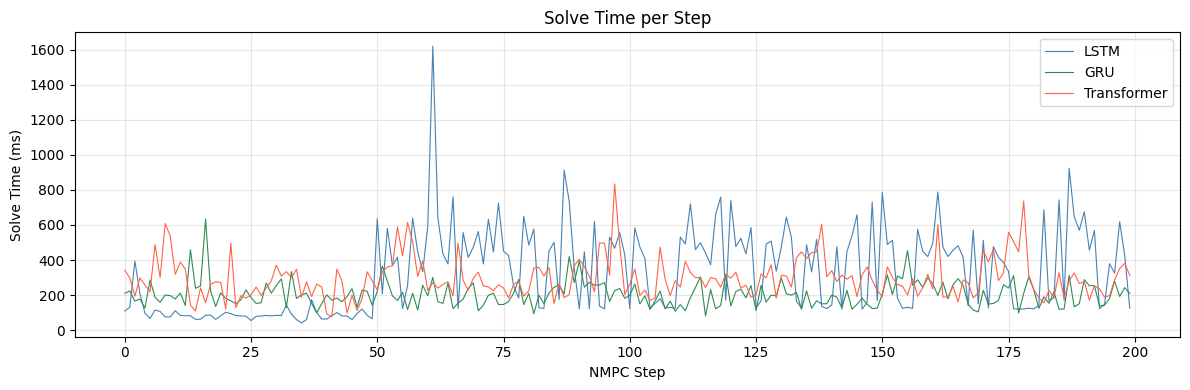

In [72]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
names  = [r["name"] for r in servo_results]
x      = np.arange(len(names))
colors = ["steelblue", "seagreen", "tomato"]

for ax, (label, vals) in zip(axes, [
    ("IAE_CA (Servo)", servo_df["IAE_CA"]),
    ("IAE_T  (Servo)", servo_df["IAE_T"]),
    ("Avg Solve (ms)", servo_df["Solve_ms"]),
]):
    bars = ax.bar(x, vals, color=colors, edgecolor="black", lw=0.8)
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)
    ax.set_title(label)
    ax.set_xticks(x)
    ax.set_xticklabels(names)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("NMPC Comparison — Servo Scenario", fontsize=13)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
for res, col in zip(servo_results, colors):
    ax.plot(res["times"] * 1000, color=col, lw=0.8, label=res["name"])
ax.set_xlabel("NMPC Step")
ax.set_ylabel("Solve Time (ms)")
ax.set_title("Solve Time per Step")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [73]:

# Build standalone test inputs (don't rely on run_nmpc's internal state)
x_buf_test  = np.tile([SS_CA_IN, SS_TIN, SS_TC], (T, 1)).astype(float)
u_prev_test = np.array([SS_CA_IN, SS_TC])
int_err_test = np.zeros(2)
state_test  = np.array([SS_CA + 0.1, SS_T + 0.5])
def diagnose_convergence(model, model_name, x_buf, y_meas, sp_k, u_prev, Tin_k, int_err, n_trials=20):
    """Check whether SLSQP is actually converging, or just running out of iterations."""
    successes, n_iters, costs = [], [], []
    for _ in range(n_trials):
        res = minimize(
            nmpc_cost_and_grad,
            x0=np.tile(u_prev, Nc).astype(np.float64),
            args=(model, x_buf, y_meas, sp_k, u_prev, Tin_k, int_err),
            jac=True, method="SLSQP", bounds=SLSQP_BOUNDS,
            options={"maxiter":150, "ftol":1e-8, "disp":False}
        )
        successes.append(res.success)
        n_iters.append(res.nit)
        costs.append(res.fun)
    print(f"{model_name:12s} | success rate: {np.mean(successes)*100:.0f}%  "
          f"| avg iters: {np.mean(n_iters):.1f}  "
          f"| hit maxiter: {sum(np.array(n_iters)>=149)}/{n_trials}  "
          f"| final cost range: [{min(costs):.4f}, {max(costs):.4f}]")

# Run on one representative state from a mid-simulation step
state_test = np.array([SS_CA+0.1, SS_T+0.5])
diagnose_convergence(lstm_model,  "LSTM",        x_buf_test, state_test, SP_servo[100], u_prev_test, SS_TIN, int_err_test)
diagnose_convergence(gru_model,   "GRU",         x_buf_test, state_test, SP_servo[100], u_prev_test, SS_TIN, int_err_test)
diagnose_convergence(trans_model, "Transformer", x_buf_test, state_test, SP_servo[100], u_prev_test, SS_TIN, int_err_test)

LSTM         | success rate: 100%  | avg iters: 32.9  | hit maxiter: 0/20  | final cost range: [0.3946, 0.3946]
GRU          | success rate: 100%  | avg iters: 8.4  | hit maxiter: 0/20  | final cost range: [0.3877, 0.3879]
Transformer  | success rate: 100%  | avg iters: 4.7  | hit maxiter: 0/20  | final cost range: [0.4150, 0.4182]


In [74]:
# Disable non-deterministic GPU kernel selection
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

# Re-run the exact same diagnostic
diagnose_convergence(lstm_model,  "LSTM",        x_buf_test, state_test, SP_servo[100], u_prev_test, SS_TIN, int_err_test)
diagnose_convergence(gru_model,   "GRU",         x_buf_test, state_test, SP_servo[100], u_prev_test, SS_TIN, int_err_test)
diagnose_convergence(trans_model, "Transformer", x_buf_test, state_test, SP_servo[100], u_prev_test, SS_TIN, int_err_test)

LSTM         | success rate: 100%  | avg iters: 33.0  | hit maxiter: 0/20  | final cost range: [0.3946, 0.3946]
GRU          | success rate: 100%  | avg iters: 8.0  | hit maxiter: 0/20  | final cost range: [0.3877, 0.3878]
Transformer  | success rate: 100%  | avg iters: 5.1  | hit maxiter: 0/20  | final cost range: [0.4145, 0.4186]


In [ ]:
# Move everything to CPU for a fully deterministic comparison
lstm_cpu  = LSTMPredictor(num_layers=2).to("cpu")
gru_cpu   = GRUPredictor(num_layers=2).to("cpu")
trans_cpu = TransformerPredictor().to("cpu")

lstm_cpu.load_state_dict(lstm_model.state_dict())
gru_cpu.load_state_dict(gru_model.state_dict())
trans_cpu.load_state_dict(trans_model.state_dict())

# Back up the GPU-resident globals so we can restore them after
_device_backup  = device
_X_mean_backup  = X_mean_t
_X_scale_backup = X_scale_t
_S_mean_backup  = S_mean_t
_S_scale_backup = S_scale_t
_W_STATE_backup = W_STATE_t
_W_DERIV_backup = W_DERIV_t

# Switch the globals nmpc_cost_and_grad actually uses to CPU versions
device    = "cpu"
X_mean_t  = X_mean_t.cpu()
X_scale_t = X_scale_t.cpu()
S_mean_t  = S_mean_t.cpu()
S_scale_t = S_scale_t.cpu()
W_STATE_t = W_STATE_t.cpu()
W_DERIV_t = W_DERIV_t.cpu()

x_buf_test_cpu = x_buf_test.copy()
state_test_cpu = state_test.copy()

diagnose_convergence(lstm_cpu,  "LSTM (CPU)",        x_buf_test_cpu, state_test_cpu, SP_servo[100], u_prev_test, SS_TIN, int_err_test)
diagnose_convergence(gru_cpu,   "GRU (CPU)",         x_buf_test_cpu, state_test_cpu, SP_servo[100], u_prev_test, SS_TIN, int_err_test)
diagnose_convergence(trans_cpu, "Transformer (CPU)", x_buf_test_cpu, state_test_cpu, SP_servo[100], u_prev_test, SS_TIN, int_err_test)

# Restore everything back to GPU for any later cells
device    = _device_backup
X_mean_t  = _X_mean_backup
X_scale_t = _X_scale_backup
S_mean_t  = _S_mean_backup
S_scale_t = _S_scale_backup
W_STATE_t = _W_STATE_backup
W_DERIV_t = _W_DERIV_backup

LSTM (CPU)   | success rate: 100%  | avg iters: 31.1  | hit maxiter: 0/20  | final cost range: [0.3946, 0.3952]
GRU (CPU)    | success rate: 100%  | avg iters: 7.3  | hit maxiter: 0/20  | final cost range: [0.3877, 0.3879]
